### A. Library Setup

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

### B. Initial Exploration

In [2]:
df = pd.read_csv("../data/raw/data_C.csv")

In [3]:
num_cols = df.select_dtypes(include=["float", "int"]).columns
cat_cols = df.select_dtypes(exclude=["float", "int"]).columns

df[num_cols].describe()

,Unnamed: 0,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month,Monthly_Balance
count,25000.000000,21164.000000,25000.000000,25000.000000,25000.000000,25000.000000,24528.000000,25000.000000,25000.000000,24699.000000
mean,12499.500000,4189.505970,18.075360,22.238000,75.407480,20.988400,28.449976,32.277257,1465.714590,403.454486
std,7217.022701,3208.575501,122.375374,126.156225,478.786499,14.851345,197.078633,5.126823,8514.582351,215.613056
min,0.000000,303.645417,-1.000000,0.000000,1.000000,-5.000000,0.000000,20.100770,0.000000,0.088628
25%,6249.750000,1611.188333,3.000000,4.000000,8.000000,10.000000,3.000000,28.043382,30.181528,269.935928
50%,12499.500000,3071.424583,6.000000,5.000000,14.000000,18.000000,6.000000,32.309314,68.248891,335.519841
75%,18749.250000,5941.093333,7.000000,7.000000,20.000000,28.000000,9.000000,36.488060,159.990097,472.202042
max,24999.000000,15204.633333,1789.000000,1498.000000,5797.000000,67.000000,2592.000000,50.000000,82331.000000,1564.134826


In [4]:
df[cat_cols].describe()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Num_of_Loan,Type_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Amount_invested_monthly,Payment_Behaviour,Credit_Score
count,25000,25000,25000,22570,25000,25000,25000,25000,25000,22148,23208,25000,25000,25000,22760,25000,23866,25000,25000
unique,25000,11254,8,8995,551,11061,16,12845,150,5731,235,3428,4,11257,403,3,22773,7,3
top,0x20419,CUS_0xb861,February,Langep,35,#F%$D@*&8,_______,35104.32,3,Not Specified,19,_,Standard,1298.38,17 Years and 11 Months,Yes,__10000__,Low_spent_Small_value_payments,Standard
freq,1,7,3203,14,743,1385,1765,7,3609,345,1370,518,9170,8,129,13082,1049,6377,13282


Data ini berisi 25 ribu baris data dan 29 kolom. Target utama dari model ini adalah memprediksi credit_score nasabah dengan klasifikasi kategori Good, Standard, Poor.

### C. Identifying Anomalies

In [5]:
df.isna().sum()

Unnamed: 0                     0
ID                             0
Customer_ID                    0
Month                          0
Name                        2430
Age                            0
SSN                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       3836
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                2852
Delay_from_due_date            0
Num_of_Delayed_Payment      1792
Changed_Credit_Limit           0
Num_Credit_Inquiries         472
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          2240
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     1134
Payment_Behaviour              0
Monthly_Balance              301
Credit_Score                   0
dtype: int64

In [6]:
df.head(5)

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x20419,CUS_0x36e1,August,Gellero,35,132-77-4921,Journalist,20364.57,1626.047500,...,Standard,2500.04,27.576478,9 Years and 8 Months,Yes,26.168109,92.51897591535379,High_spent_Small_value_payments,303.917665,Standard
1,1,0x4579,CUS_0x2a61,August,NaN,46,753-68-0048,Teacher,9786.86,951.571667,...,Standard,2149.9,23.451285,NaN,Yes,11.564437,54.46174813453877,Low_spent_Medium_value_payments,309.130981,Poor
2,2,0x1b923,CUS_0x788b,June,Ben Klaymane,19,276-42-6585,_______,146880.84,12372.070000,...,Good,387.53,31.100297,24 Years and 3 Months,No,98.031931,478.3574716999517,High_spent_Small_value_payments,920.817597,Standard
3,3,0x8ac9,CUS_0x5534,April,Aubinr,39,246-34-3138,Developer,23200.82,NaN,...,Standard,987.07,26.786925,17 Years and 7 Months,Yes,0.000000,65.84983488267585,Low_spent_Large_value_payments,391.890332,Standard
4,4,0x24a41,CUS_0x104f,April,Markm,20,264-84-8069,Architect,11336.835,992.736250,...,Standard,177.98,24.001752,14 Years and 7 Months,Yes,35.562731,NaN,Low_spent_Small_value_payments,228.245999,Standard


In [7]:
cat_cols = df.select_dtypes(exclude=["float", "int"]).columns

Tahap awal identifikasi anomali menunjukan perlunya pemeriksaan struktur data, tipe data, dan missing value. Banyak kolom kategori yang seharusnya adalah kolom numerik (dibaca sebagai object). dan adanya nilai kosong dengan kolom terparah yaitu 'Monthly_Inhand_Salary' & 'Type_of_Loan' dengan missing value sebesar ~3k.



#### C.2 Categorical Column Anomalies

In [8]:
df.columns

Index(['Unnamed: 0', 'ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN',
       'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
       'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [9]:
df[cat_cols].head(10)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Num_of_Loan,Type_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Amount_invested_monthly,Payment_Behaviour,Credit_Score
0,0x20419,CUS_0x36e1,August,Gellero,35,132-77-4921,Journalist,20364.57,3,"Personal Loan, Student Loan, and Mortgage Loan",9,10.3,Standard,2500.04,9 Years and 8 Months,Yes,92.51897591535379,High_spent_Small_value_payments,Standard
1,0x4579,CUS_0x2a61,August,NaN,46,753-68-0048,Teacher,9786.86,2,"Personal Loan, and Student Loan",14,15.53,Standard,2149.9,NaN,Yes,54.46174813453877,Low_spent_Medium_value_payments,Poor
2,0x1b923,CUS_0x788b,June,Ben Klaymane,19,276-42-6585,_______,146880.84,1,Auto Loan,4,5.04,Good,387.53,24 Years and 3 Months,No,478.3574716999517,High_spent_Small_value_payments,Standard
3,0x8ac9,CUS_0x5534,April,Aubinr,39,246-34-3138,Developer,23200.82,0,NaN,15,24.73,Standard,987.07,17 Years and 7 Months,Yes,65.84983488267585,Low_spent_Large_value_payments,Standard
4,0x24a41,CUS_0x104f,April,Markm,20,264-84-8069,Architect,11336.835,6,"Auto Loan, Payday Loan, Student Loan, Auto Loa...",19,16.44,Standard,177.98,14 Years and 7 Months,Yes,NaN,Low_spent_Small_value_payments,Standard
5,0x16099,CUS_0x6573,August,Jamesp,34,682-25-4861,Doctor,8922.155,7,"Personal Loan, Auto Loan, Credit-Builder Loan,...",NaN,18.61,Bad,4648.32,2 Years and 4 Months,Yes,102.11048074801573,!@9#%8,Good
6,0x23e35,CUS_0xb3c2,April,Shirbonv,35,#F%$D@*&8,Media_Manager,20487.905,3,"Mortgage Loan, Payday Loan, and Credit-Builder...",NaN,6.05,Good,1464.77,20 Years and 11 Months,No,64.78254782421534,High_spent_Medium_value_payments,Standard
7,0x19cd4,CUS_0xba0b,July,Leah Schnurro,34,165-76-8590,Accountant,54265.54,2,"Mortgage Loan, and Student Loan",13,4.78,Standard,545.37,23 Years and 5 Months,No,396.4845290738466,Low_spent_Small_value_payments,Good
8,0x14c0d,CUS_0x38d8,April,Nishant Kumart,24,467-02-8866,Accountant,101114.73,3,"Personal Loan, Home Equity Loan, and Student Loan",11,24.91,_,1190.45,NaN,Yes,116.52344476791184,High_spent_Large_value_payments,Good
9,0x1298f,CUS_0x51a1,June,NaN,45,959-74-6872,Entrepreneur,63306.54,3,"Student Loan, Mortgage Loan, and Student Loan",9,8.09,Standard,1203.19,28 Years and 2 Months,No,120.0391513715411,High_spent_Large_value_payments,Standard


Penanganan Anomali & Pembersihan Data:
- Casting Column:
    - Age -> int
    - Num_of_loan -> int
    - Annual_Income -> Float
    - Num_of_Delayed_Payment -> int
    - Changed_Credit_Limit -> Float
    - Outstanding_debt -> Float
    - Credit_History_Age -> Date
    - Amount_invested_monthly -> Float

- Invalid Value:
    - Occupational ada nilai: '___', ganti dengan 'Unknown'

- Special Treatment:
    - Type_of_Loan: Information dense & high cardinality
    - Payment_Behaviour: Information dense & high cardinality

In [10]:
df[cat_cols].nunique()

ID                         25000
Customer_ID                11254
Month                          8
Name                        8995
Age                          551
SSN                        11061
Occupation                    16
Annual_Income              12845
Num_of_Loan                  150
Type_of_Loan                5731
Num_of_Delayed_Payment       235
Changed_Credit_Limit        3428
Credit_Mix                     4
Outstanding_Debt           11257
Credit_History_Age           403
Payment_of_Min_Amount          3
Amount_invested_monthly    22773
Payment_Behaviour              7
Credit_Score                   3
dtype: int64

##### C.2.1 Solving Column Type Anomaly via Casting

In [ ]:
#Fungsi otomatis casting str type column -> Num (float, int) column
df["Age"] = pd.to_numeric(
    df["Age"],
    errors="coerce"
)

df["Annual_Income"] = pd.to_numeric(
    df["Annual_Income"],
    errors="coerce"
)

df["Num_of_Loan"] = pd.to_numeric(
    df["Num_of_Loan"],
    errors="coerce"
)

#Membersihkan teks string menjadi angka saja jika ada whitespace
df["Num_of_Delayed_Payment"] = (
    df["Num_of_Delayed_Payment"]
    .astype(str)
    .str.replace(r"[^\d]", "", regex=True)
)

df["Num_of_Delayed_Payment"] = pd.to_numeric(
    df["Num_of_Delayed_Payment"],
    errors="coerce"
)

df["Changed_Credit_Limit"] = pd.to_numeric(
    df["Changed_Credit_Limit"],
    errors="coerce"
)

df["Outstanding_Debt"] = pd.to_numeric(
    df["Outstanding_Debt"],
    errors="coerce"
)

df["Amount_invested_monthly"] = pd.to_numeric(
    df["Amount_invested_monthly"],
    errors="coerce"
)

#Fungsi mengubah Credit_History_Age_Months menjadi jumlah months saja
def history_to_months(x):
    if pd.isna(x):
        return np.nan

    match = re.search(r"(\d+)\s+Years?\s+and\s+(\d+)\s+Months?", str(x)) #Identifikasi value years dan months

    if match: #ubah semuanya menjadi total months
        years = int(match.group(1))
        months = int(match.group(2))
        return years * 12 + months

    return np.nan

df["Credit_History_Age_Months"] = (
    df["Credit_History_Age"].apply(history_to_months)
)

df = df.drop(columns=["Credit_History_Age"])

cat_cols = df.select_dtypes(exclude=["float64", "int64"]).columns

In [13]:
df[cat_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   ID                     25000 non-null  object
 1   Customer_ID            25000 non-null  object
 2   Month                  25000 non-null  object
 3   Name                   22570 non-null  object
 4   SSN                    25000 non-null  object
 5   Occupation             25000 non-null  object
 6   Type_of_Loan           22148 non-null  object
 7   Credit_Mix             25000 non-null  object
 8   Payment_of_Min_Amount  25000 non-null  object
 9   Payment_Behaviour      25000 non-null  object
 10  Credit_Score           25000 non-null  object
dtypes: object(11)
memory usage: 2.1+ MB


In [14]:
df[cat_cols].nunique()

ID                       25000
Customer_ID              11254
Month                        8
Name                      8995
SSN                      11061
Occupation                  16
Type_of_Loan              5731
Credit_Mix                   4
Payment_of_Min_Amount        3
Payment_Behaviour            7
Credit_Score                 3
dtype: int64

In [15]:
df["Occupation"] = df["Occupation"].replace("_______", "Unknown")

In [16]:
df["Occupation"].value_counts()

Occupation
Unknown          1765
Lawyer           1642
Mechanic         1621
Teacher          1618
Developer        1580
Journalist       1568
Scientist        1558
Accountant       1553
Media_Manager    1552
Architect        1550
Engineer         1549
Entrepreneur     1511
Doctor           1504
Manager          1497
Musician         1491
Writer           1441
Name: count, dtype: int64

##### C.2.2 Solving Special Treatment Column (Feature Engineering)

Column Payment_Behaviour Mengandung 2 informasi:
- Spending_Level: High_spent / Low_spent
- Payment_Size: Small / Medium / High

In [17]:
df["Spending_Level"] = (
    df["Payment_Behaviour"]
    .str.extract(r"(High_spent|Low_spent)")
    .fillna("Unknown")
)

df["Payment_Size"] = (
    df["Payment_Behaviour"]
    .str.extract(r"(Small|Medium|Large)")
    .fillna("Unknown")
)

df.drop(columns=["Payment_Behaviour"], inplace=True)

Create Column Type_of_Loan

In [ ]:
all_loans = ( #Buat list Tipe Loan
    df["Type_of_Loan"]
    .dropna()
    .str.replace(" and ", ", ", regex=False) #ubah 'and' menjadi , agar lebih rapi
    .str.split(",") #pisah teks berdasarkan ,
    .explode() #pecah isi list menjadi baris baru
    .str.strip(" ,") #pisah teks berdasarkan ,
)

print(all_loans.value_counts())
print(all_loans.nunique())

Type_of_Loan
                           19321
Payday Loan                10181
Credit-Builder Loan        10024
Not Specified               9796
Personal Loan               9793
Student Loan                9775
Debt Consolidation Loan     9698
Home Equity Loan            9657
Mortgage Loan               9642
Auto Loan                   9449
Name: count, dtype: int64
10


Buat column Tipe Loan baru dengan informasi independen

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

loan_lists = (df["Type_of_Loan"] #Buat list apa saj isi value
              .fillna("")
              .str.replace(" and ", ", ", regex=False)
              .str.split(",")
              .apply(lambda x: [i.strip() for i in x if i.strip()]))

mlb = MultiLabelBinarizer() #Fungsi untuk membuat kolom baru untuk tiap informasi
loan_binary_array = mlb.fit_transform(loan_lists)

columns_with_prefix = [f"Loan_{c.replace(' ', '_').replace('-', '_')}" for c in mlb.classes_] 
#buatkan prefix Loan_ untuk tiap kolom baru

loan_df = pd.DataFrame( #tampung hasil kolom transformasi baru
    loan_binary_array, 
    columns=columns_with_prefix, 
    index=df.index
).astype(np.int8) 

df = pd.concat([df, loan_df], axis=1) #Join data dengan df kita

In [ ]:
cat_cols = df.select_dtypes(exclude=["float", "int"]).columns
num_cols = df.select_dtypes(include=["float", "int"]).columns
#Update list categorical dan numeric

df[cat_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   ID                            25000 non-null  object
 1   Customer_ID                   25000 non-null  object
 2   Month                         25000 non-null  object
 3   Name                          22570 non-null  object
 4   SSN                           25000 non-null  object
 5   Occupation                    25000 non-null  object
 6   Type_of_Loan                  22148 non-null  object
 7   Credit_Mix                    25000 non-null  object
 8   Payment_of_Min_Amount         25000 non-null  object
 9   Credit_Score                  25000 non-null  object
 10  Spending_Level                25000 non-null  object
 11  Payment_Size                  25000 non-null  object
 12  Loan_Auto_Loan                25000 non-null  int8  
 13  Loan_Credit_Buil

In [22]:
df[cat_cols].nunique()

ID                              25000
Customer_ID                     11254
Month                               8
Name                             8995
SSN                             11061
Occupation                         16
Type_of_Loan                     5731
Credit_Mix                          4
Payment_of_Min_Amount               3
Credit_Score                        3
Spending_Level                      3
Payment_Size                        4
Loan_Auto_Loan                      2
Loan_Credit_Builder_Loan            2
Loan_Debt_Consolidation_Loan        2
Loan_Home_Equity_Loan               2
Loan_Mortgage_Loan                  2
Loan_Not_Specified                  2
Loan_Payday_Loan                    2
Loan_Personal_Loan                  2
Loan_Student_Loan                   2
dtype: int64

In [23]:
df[num_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    25000 non-null  int64  
 1   Age                           23755 non-null  float64
 2   Annual_Income                 23222 non-null  float64
 3   Monthly_Inhand_Salary         21164 non-null  float64
 4   Num_Bank_Accounts             25000 non-null  int64  
 5   Num_Credit_Card               25000 non-null  int64  
 6   Interest_Rate                 25000 non-null  int64  
 7   Num_of_Loan                   23796 non-null  float64
 8   Delay_from_due_date           25000 non-null  int64  
 9   Num_of_Delayed_Payment        23208 non-null  float64
 10  Changed_Credit_Limit          24482 non-null  float64
 11  Num_Credit_Inquiries          24528 non-null  float64
 12  Outstanding_Debt              24730 non-null  float64
 13  C

##### C.2.3 Final Categorical Assesment Before Deleting High Cardinality Column

In [24]:
df[cat_cols].head(10)

,ID,Customer_ID,Month,Name,SSN,Occupation,Type_of_Loan,Credit_Mix,Payment_of_Min_Amount,Credit_Score,...,Payment_Size,Loan_Auto_Loan,Loan_Credit_Builder_Loan,Loan_Debt_Consolidation_Loan,Loan_Home_Equity_Loan,Loan_Mortgage_Loan,Loan_Not_Specified,Loan_Payday_Loan,Loan_Personal_Loan,Loan_Student_Loan
0,0x20419,CUS_0x36e1,August,Gellero,132-77-4921,Journalist,"Personal Loan, Student Loan, and Mortgage Loan",Standard,Yes,Standard,...,Small,0,0,0,0,1,0,0,1,1
1,0x4579,CUS_0x2a61,August,NaN,753-68-0048,Teacher,"Personal Loan, and Student Loan",Standard,Yes,Poor,...,Medium,0,0,0,0,0,0,0,1,1
2,0x1b923,CUS_0x788b,June,Ben Klaymane,276-42-6585,Unknown,Auto Loan,Good,No,Standard,...,Small,1,0,0,0,0,0,0,0,0
3,0x8ac9,CUS_0x5534,April,Aubinr,246-34-3138,Developer,NaN,Standard,Yes,Standard,...,Large,0,0,0,0,0,0,0,0,0
4,0x24a41,CUS_0x104f,April,Markm,264-84-8069,Architect,"Auto Loan, Payday Loan, Student Loan, Auto Loa...",Standard,Yes,Standard,...,Small,1,0,0,0,0,0,1,1,1
5,0x16099,CUS_0x6573,August,Jamesp,682-25-4861,Doctor,"Personal Loan, Auto Loan, Credit-Builder Loan,...",Bad,Yes,Good,...,Unknown,1,1,0,1,0,0,1,1,0
6,0x23e35,CUS_0xb3c2,April,Shirbonv,#F%$D@*&8,Media_Manager,"Mortgage Loan, Payday Loan, and Credit-Builder...",Good,No,Standard,...,Medium,0,1,0,0,1,0,1,0,0
7,0x19cd4,CUS_0xba0b,July,Leah Schnurro,165-76-8590,Accountant,"Mortgage Loan, and Student Loan",Standard,No,Good,...,Small,0,0,0,0,1,0,0,0,1
8,0x14c0d,CUS_0x38d8,April,Nishant Kumart,467-02-8866,Accountant,"Personal Loan, Home Equity Loan, and Student Loan",_,Yes,Good,...,Large,0,0,0,1,0,0,0,1,1
9,0x1298f,CUS_0x51a1,June,NaN,959-74-6872,Entrepreneur,"Student Loan, Mortgage Loan, and Student Loan",Standard,No,Standard,...,Large,0,0,0,0,1,0,0,0,1


In [25]:
df[cat_cols].nunique()

ID                              25000
Customer_ID                     11254
Month                               8
Name                             8995
SSN                             11061
Occupation                         16
Type_of_Loan                     5731
Credit_Mix                          4
Payment_of_Min_Amount               3
Credit_Score                        3
Spending_Level                      3
Payment_Size                        4
Loan_Auto_Loan                      2
Loan_Credit_Builder_Loan            2
Loan_Debt_Consolidation_Loan        2
Loan_Home_Equity_Loan               2
Loan_Mortgage_Loan                  2
Loan_Not_Specified                  2
Loan_Payday_Loan                    2
Loan_Personal_Loan                  2
Loan_Student_Loan                   2
dtype: int64

Column List yang akan di drop nanti:
- Masalah High Cardinality:
    - ID & CustomerID
    - Name
    - SSN

In [26]:
df["Credit_Mix"].value_counts()

Credit_Mix
Standard    9170
Good        6123
_           4926
Bad         4781
Name: count, dtype: int64

In [27]:
df["Credit_Mix"] = df["Credit_Mix"].replace("_", "Unknown")

In [28]:
df["Credit_Mix"].value_counts()

Credit_Mix
Standard    9170
Good        6123
Unknown     4926
Bad         4781
Name: count, dtype: int64

In [29]:
df[cat_cols].isna().sum()

ID                                 0
Customer_ID                        0
Month                              0
Name                            2430
SSN                                0
Occupation                         0
Type_of_Loan                    2852
Credit_Mix                         0
Payment_of_Min_Amount              0
Credit_Score                       0
Spending_Level                     0
Payment_Size                       0
Loan_Auto_Loan                     0
Loan_Credit_Builder_Loan           0
Loan_Debt_Consolidation_Loan       0
Loan_Home_Equity_Loan              0
Loan_Mortgage_Loan                 0
Loan_Not_Specified                 0
Loan_Payday_Loan                   0
Loan_Personal_Loan                 0
Loan_Student_Loan                  0
dtype: int64

#### C.3. Numerical Column Anomalies

In [30]:
df.columns

Index(['Unnamed: 0', 'ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN',
       'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
       'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Payment_of_Min_Amount',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance',
       'Credit_Score', 'Credit_History_Age_Months', 'Spending_Level',
       'Payment_Size', 'loan_unknown', 'loan_payday_loan',
       'loan_credit_builder_loan', 'loan_not_specified', 'loan_personal_loan',
       'loan_student_loan', 'loan_debt_consolidation_loan',
       'loan_home_equity_loan', 'loan_mortgage_loan', 'loan_auto_loan',
       'Loan_Count', 'Loan_Auto_Loan', 'Loan_Credit_Builder_Loan',
       'Loan_Debt_Consolidation_Loan', 'Loan_Home_Equity_Loan',
       'Loan_Mort

In [31]:
display(df[num_cols].describe())

,Unnamed: 0,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,loan_payday_loan,loan_credit_builder_loan,loan_not_specified,loan_personal_loan,loan_student_loan,loan_debt_consolidation_loan,loan_home_equity_loan,loan_mortgage_loan,loan_auto_loan,Loan_Count
count,25000.000000,23755.000000,2.322200e+04,21164.000000,25000.000000,25000.000000,25000.000000,23796.000000,25000.000000,23208.000000,...,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000
mean,12499.500000,108.037508,1.646632e+05,4189.505970,18.075360,22.238000,75.407480,3.005925,20.988400,30.144088,...,0.322120,0.316040,0.312640,0.31416,0.311320,0.311120,0.31188,0.312840,0.305880,3.520600
std,7217.022701,673.017659,1.360754e+06,3208.575501,122.375374,126.156225,478.786499,63.687393,14.851345,220.644654,...,0.467298,0.464938,0.463578,0.46419,0.463043,0.462961,0.46327,0.463659,0.460788,2.438092
min,0.000000,-500.000000,7.005930e+03,303.645417,-1.000000,0.000000,1.000000,-100.000000,-5.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,6249.750000,24.000000,1.919785e+04,1611.188333,3.000000,4.000000,8.000000,1.000000,10.000000,9.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,2.000000
50%,12499.500000,33.000000,3.730210e+04,3071.424583,6.000000,5.000000,14.000000,3.000000,18.000000,14.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,3.000000
75%,18749.250000,42.000000,7.274096e+04,5941.093333,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,...,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.00000,1.000000,1.000000,5.000000
max,24999.000000,8697.000000,2.416001e+07,15204.633333,1789.000000,1498.000000,5797.000000,1495.000000,67.000000,4384.000000,...,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.00000,1.000000,1.000000,9.000000


Abnormalitas Terdeteksi:
- Age: nilai minus dan maks 8697
- Annual_Income: standar deviasi 1.360754e+06 dengan maks 2.416001e+07 memerlukan plotting untuk melihat anomali
- Monthly_Inhand_Salary: lonjakan besar antara min dan maks, memerlukan plotting
- Num_Credit_Card: maks 1498 kemungkinan error
- Interest_Rate: Nilai maks yang dipertanyakan sebesar 5797%
- Delay_from_due_date: tanggal minus
- Changed_Credit_Limit: nilai minus

A lot of missing value is detected:
Age, Annual_Income, Monthly_Inhand_Salary, Num_of_Loan, Delay_from_due_date, Num_of_Delayed_Payment. Hampir semua kolom ini kehilangan ~1k+ nilai. Banyak imputasi dan inspeksi yang perlu dilakukan.

##### C.3.1 Age

In [32]:
invalid_age = df[
    (df["Age"] < 18) |
    (df["Age"] > 100)
]

invalid_age["Age"].value_counts().sort_index().sum()

np.int64(2082)

In [33]:
(df["Age"] < 18).sum()

np.int64(1634)

Kolom Age memiliki karakteristik:
- Salah input Age di januari namun benar input Age di Febuari dengan customerID yang sama.

Imputasi Age menggunakan CustomerID yang sama.

In [34]:
df.loc[(df["Age"] < 18) | (df["Age"] > 100), "Age"] = np.nan
df["Age"] = df.groupby("Customer_ID")["Age"].ffill().bfill()

In [35]:
df['Age'].isna().sum()

np.int64(0)

In [36]:
df["Age"].describe()

count    25000.000000
mean        34.269760
std         10.067985
min         18.000000
25%         26.000000
50%         34.000000
75%         42.000000
max         95.000000
Name: Age, dtype: float64

##### C.3.2 Annual_Income

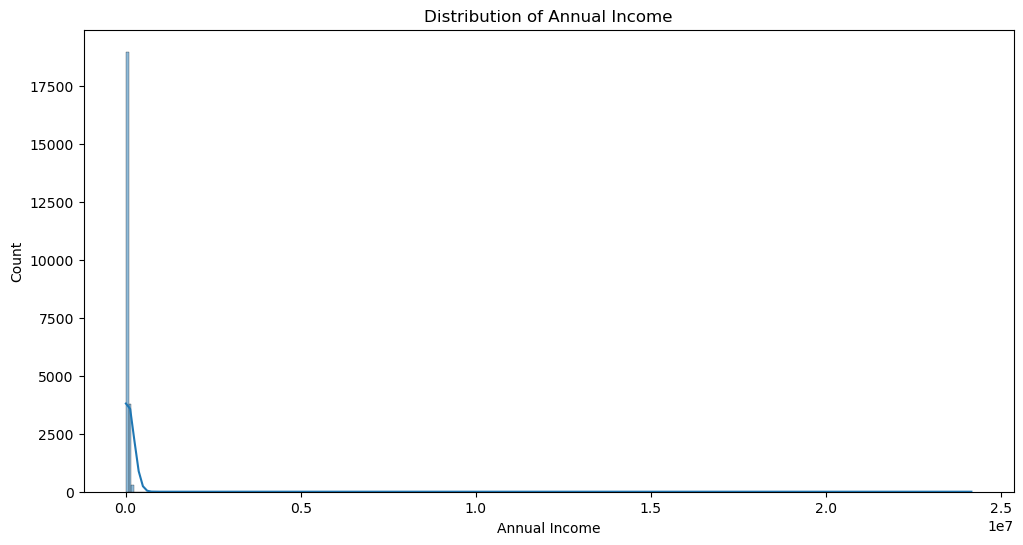

In [37]:
plt.figure(figsize=(12, 6))
# Filter visualisasi tanpa mengubah dataframe asli
sns.histplot(df["Annual_Income"], kde=True)

plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Count")
plt.show()

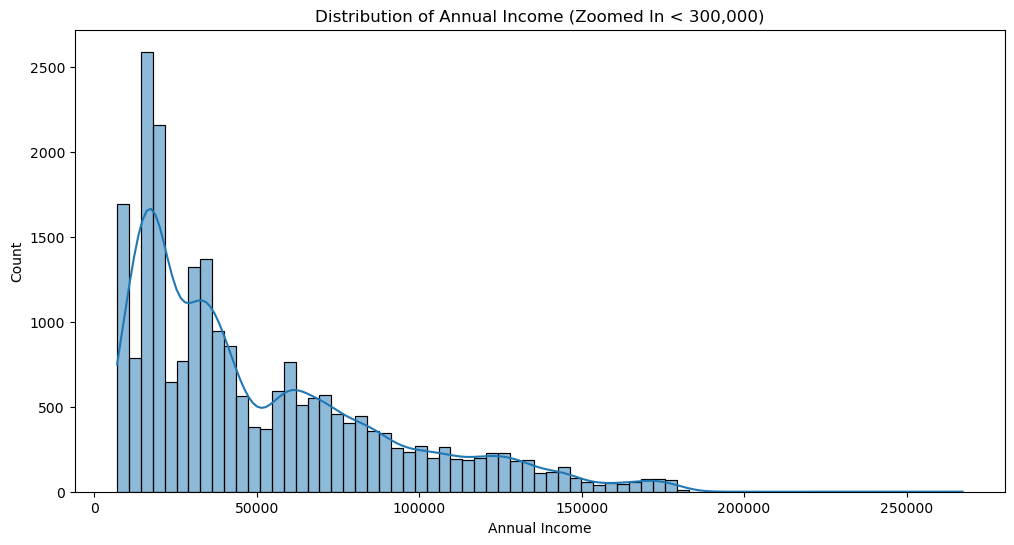

In [38]:
plt.figure(figsize=(12, 6))
# Filter visualisasi tanpa mengubah dataframe asli
sns.histplot(df[df["Annual_Income"] < 300000]["Annual_Income"], kde=True)

plt.title("Distribution of Annual Income (Zoomed In < 300,000)")
plt.xlabel("Annual Income")
plt.ylabel("Count")
plt.show()

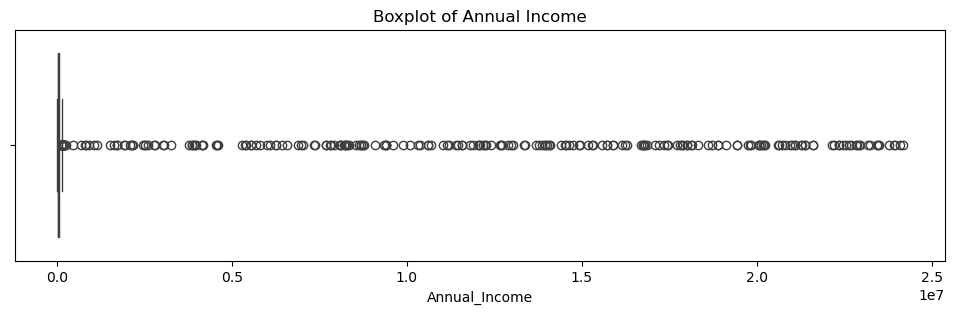

In [39]:
plt.figure(figsize=(12, 3))
sns.boxplot(x=df["Annual_Income"])
plt.title("Boxplot of Annual Income")
plt.show()

In [ ]:
def filter_outlier(df, column): #Fungsi Filter IQR
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[df[column] > upper_bound]
    print(f"Jumlah outlier: {len(outliers)}")
    print(f"Upper Bound {column}: {upper_bound:.2f}")

    return outliers, upper_bound

def find_outlier(df, upper_bound, column): #Fungsi melihat outlier tersisa
    outliers = df[df[column] > upper_bound]
    print(f"Jumlah outlier: {len(outliers)}")
    print(f"Upper Bound {column}: {upper_bound:.2f}")

outliers, upper_annual  = filter_outlier(df, "Annual_Income") #Filter

outliers[["Age", "Occupation", "Annual_Income"]].sort_values(by="Annual_Income", ascending=False).head(10)

Jumlah outlier: 639
Upper Bound Annual_Income: 153055.63


,Age,Occupation,Annual_Income
1566,38.0,Teacher,24160009.0
21484,19.0,Engineer,24096975.0
18699,51.0,Mechanic,23942655.0
23439,28.0,Manager,23912939.0
21703,32.0,Journalist,23775314.0
9840,27.0,Developer,23498432.0
24847,39.0,Unknown,23467279.0
24695,37.0,Architect,23435862.0
11329,21.0,Media_Manager,23229157.0
7114,33.0,Engineer,23176251.0


In [ ]:
df.loc[df['Annual_Income'] > upper_annual, 'Annual_Income'] = np.nan #isi nilai kolom diatas upper bound dengan nan

df['Annual_Income'] = df.groupby('Occupation')['Annual_Income'].transform(
    lambda x: x.fillna(x.median())
) #Replace nilainya dengan median

find_outlier(df, upper_annual, "Annual_Income")

Jumlah outlier: 0
Upper Bound Annual_Income: 153055.63


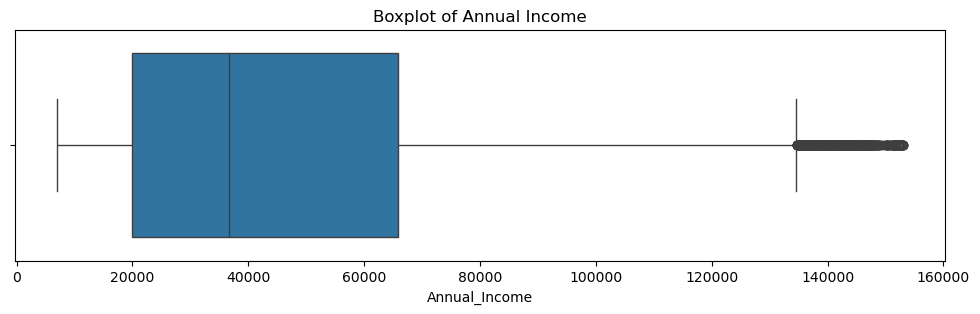

In [ ]:
plt.figure(figsize=(12, 3))
sns.boxplot(x=df["Annual_Income"]) #jumlah outlier baru
plt.title("Boxplot of Annual Income")
plt.show()

##### C.3.3 Interest_Rate

Top 10 Interest Rates:
[5797 5763 5752 5745 5743 5737 5731 5713 5710 5704]


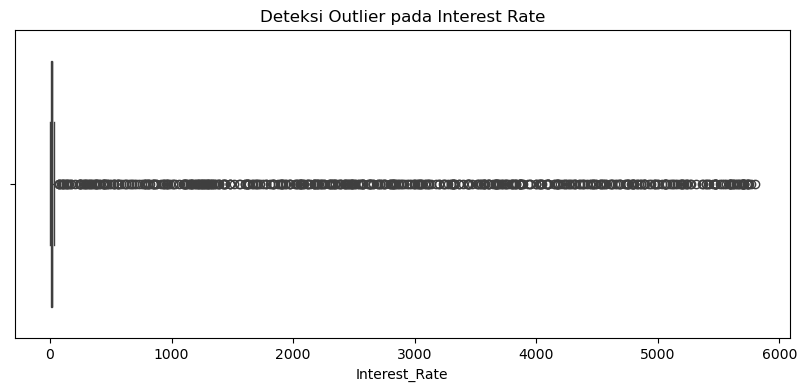

In [43]:
print("Top 10 Interest Rates:")
print(df['Interest_Rate'].sort_values(ascending=False).unique()[:10])

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Interest_Rate'])
plt.title("Deteksi Outlier pada Interest Rate")
plt.show()

In [44]:
df["Interest_Rate"].describe()

count    25000.000000
mean        75.407480
std        478.786499
min          1.000000
25%          8.000000
50%         14.000000
75%         20.000000
max       5797.000000
Name: Interest_Rate, dtype: float64

In [45]:
outliers, upper_interest = filter_outlier(df, "Interest_Rate")

Jumlah outlier: 534
Upper Bound Interest_Rate: 38.00


Lakukan imputasi berdasarkan suku bunga per customer_ID

In [46]:
df.loc[df['Interest_Rate'] > upper_interest, 'Interest_Rate'] = np.nan
df['Interest_Rate'] = df.groupby('Customer_ID')['Interest_Rate'].ffill().bfill()


In [47]:
df["Interest_Rate"].isna().sum()

np.int64(0)

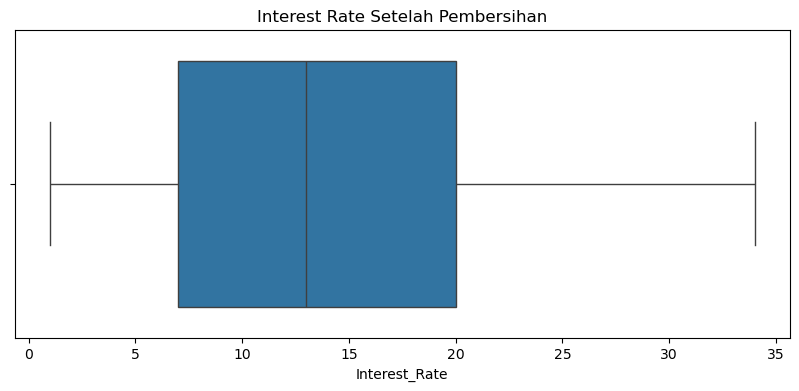

In [48]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Interest_Rate'])
plt.title("Interest Rate Setelah Pembersihan")
plt.show()

##### C.3.4 Monthly_Inhand_Salary

In [49]:
print("Missing value:", df["Monthly_Inhand_Salary"].isna().sum())
df["Monthly_Inhand_Salary"].describe()

Missing value: 3836


count    21164.000000
mean      4189.505970
std       3208.575501
min        303.645417
25%       1611.188333
50%       3071.424583
75%       5941.093333
max      15204.633333
Name: Monthly_Inhand_Salary, dtype: float64

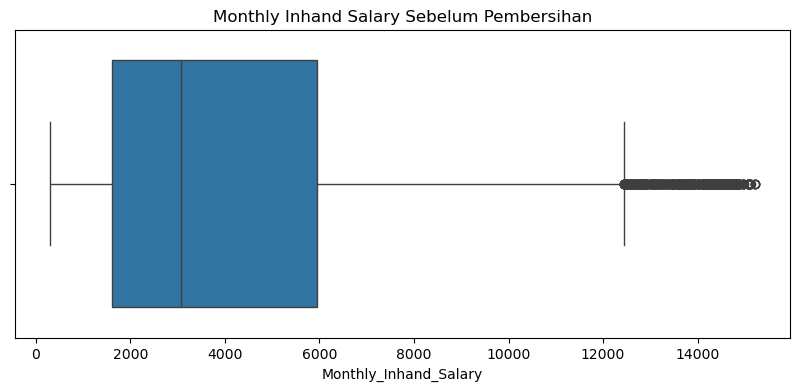

In [50]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Monthly_Inhand_Salary'])
plt.title("Monthly Inhand Salary Sebelum Pembersihan")
plt.show()

In [51]:
outliers, upper_salary = filter_outlier(df, "Monthly_Inhand_Salary")

Jumlah outlier: 444
Upper Bound Monthly_Inhand_Salary: 12435.95


Bandingkan Upper Bound Annual_Income: 153055.63
dengan Upper Bound Monthly_Inhand_Salary: 12435.95

Bandingkan Gaji Kotor per bulan: 
- 153055.63 / 12 = 12.754.63 -> Masuk Akal

Bandingkan Gaji Bersih per tahun:
- 12435.95 * 12 = 149.231 -> Masuk Akal

Bandingkan Max Gaji Bersih dengan Upper Bound Gaji kotor:
- 15204.63 vs 12435.95 -> Terjadi kesenjangan besar

Annual_Income (Gaji Kotor per tahun) dan Monthly_Inhand_Salary (Gaji Bersih per bulan) merupakan kolom yang saling berelasi.

Adanya nasabah dengan gaji bersih bulannya $15,204.63 per bulan ($182,455.56 per tahun) dibanding upper bound gaji kotor per tahun $153,055.63, memiliki selisih sebesar $29,400.

Solusi: Imputasi Gaji Bersih per bulan berdasarkan Customer ID

In [52]:
df['Monthly_Inhand_Salary'] = df.groupby('Customer_ID')['Monthly_Inhand_Salary'].ffill().bfill()
df['Monthly_Inhand_Salary'] = df.groupby('Occupation')['Monthly_Inhand_Salary'].transform(
    lambda x: x.fillna(x.median())
)
df['Monthly_Inhand_Salary'] = df['Monthly_Inhand_Salary'].clip(upper=upper_salary)

find_outlier(df, upper_salary, "Monthly_Inhand_Salary")

Jumlah outlier: 0
Upper Bound Monthly_Inhand_Salary: 12435.95


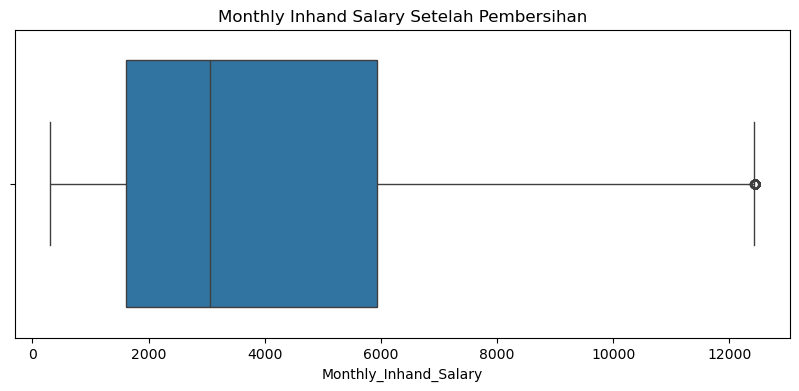

In [53]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Monthly_Inhand_Salary'])
plt.title("Monthly Inhand Salary Setelah Pembersihan")
plt.show()

##### C.3.5 Num_Credit_Card

In [54]:
df["Num_Credit_Card"].describe()

count    25000.000000
mean        22.238000
std        126.156225
min          0.000000
25%          4.000000
50%          5.000000
75%          7.000000
max       1498.000000
Name: Num_Credit_Card, dtype: float64

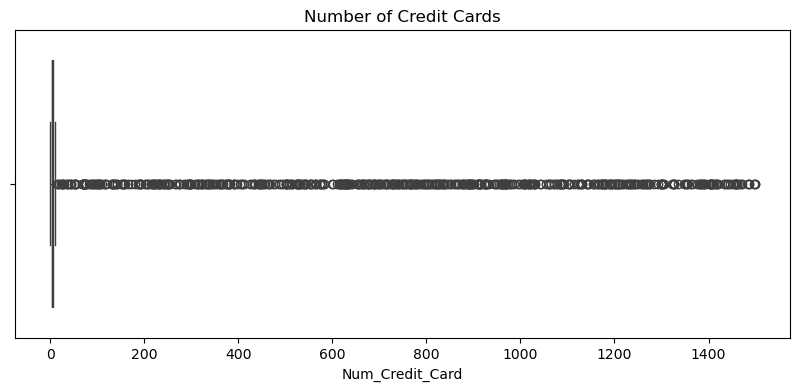

In [55]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["Num_Credit_Card"])
plt.title("Number of Credit Cards")
plt.show()

In [56]:
outliers, upper_credit = filter_outlier(df, "Num_Credit_Card")

Jumlah outlier: 569
Upper Bound Num_Credit_Card: 11.50


In [57]:
df.loc[df['Num_Credit_Card'] > 12, 'Num_Credit_Card'] = np.nan
df['Num_Credit_Card'] = df.groupby('Customer_ID')['Num_Credit_Card'].ffill().bfill()
df['Num_Credit_Card'] = df['Num_Credit_Card'].fillna(df['Num_Credit_Card'].median())

In [58]:
find_outlier(df, upper_credit, "Num_Credit_Card")

Jumlah outlier: 0
Upper Bound Num_Credit_Card: 11.50


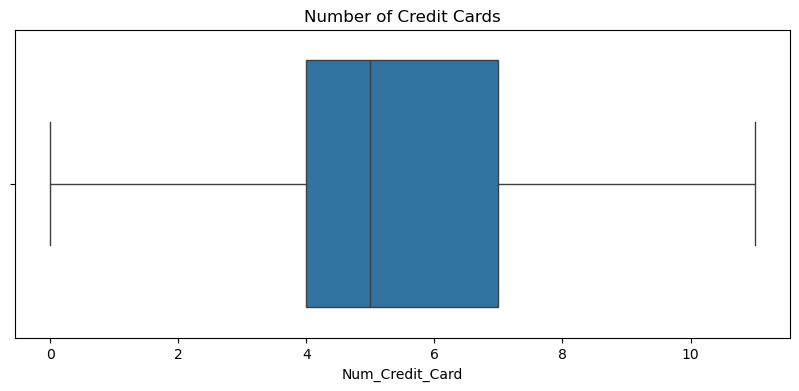

In [59]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["Num_Credit_Card"])
plt.title("Number of Credit Cards")
plt.show()

##### C.3.6 Delay from Due Date

In [60]:
df["Delay_from_due_date"].describe()

count    25000.000000
mean        20.988400
std         14.851345
min         -5.000000
25%         10.000000
50%         18.000000
75%         28.000000
max         67.000000
Name: Delay_from_due_date, dtype: float64

Dalam domain finansial, jika seseorang membayar sebelum tanggal jatuh tempo, sistem perbankan terkadang mencatatnya sebagai angka negatif (misal, telat -5 hari artinya mempercepat pembayaran 5 hari). Namun, untuk kebutuhan pemodelan Credit Scoring, fokus utama kita adalah risiko kegagalan/keterlambatan.

Membayar lebih cepat 1 hari atau 5 hari sama-sama bermakna "Nasabah tidak terlambat". Oleh karena itu, mempertahankan nilai minus tidak akan memberikan informasi tambahan yang berarti bagi model, dan justru bisa membingungkannya.

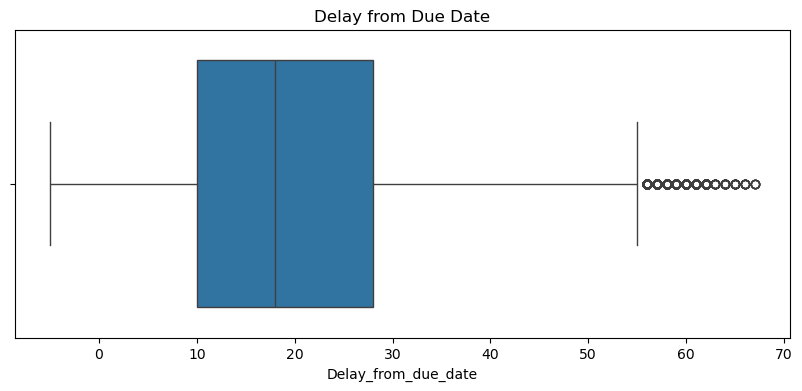

In [61]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["Delay_from_due_date"])
plt.title("Delay from Due Date")
plt.show()

In [62]:
df['Delay_from_due_date'] = df['Delay_from_due_date'].clip(lower=0)
df['Delay_from_due_date'] = df.groupby('Customer_ID')['Delay_from_due_date'].ffill().bfill()
df['Delay_from_due_date'] = df['Delay_from_due_date'].fillna(df['Delay_from_due_date'].median())

In [63]:
print(df['Delay_from_due_date'].describe())

count    25000.000000
mean        20.999720
std         14.834278
min          0.000000
25%         10.000000
50%         18.000000
75%         28.000000
max         67.000000
Name: Delay_from_due_date, dtype: float64


##### C.3.7 Changed Credit_Limit

In [64]:
df["Changed_Credit_Limit"].describe()

count    24482.000000
mean        10.392018
std          6.812396
min         -6.480000
25%          5.300000
50%          9.440000
75%         14.910000
max         35.820000
Name: Changed_Credit_Limit, dtype: float64

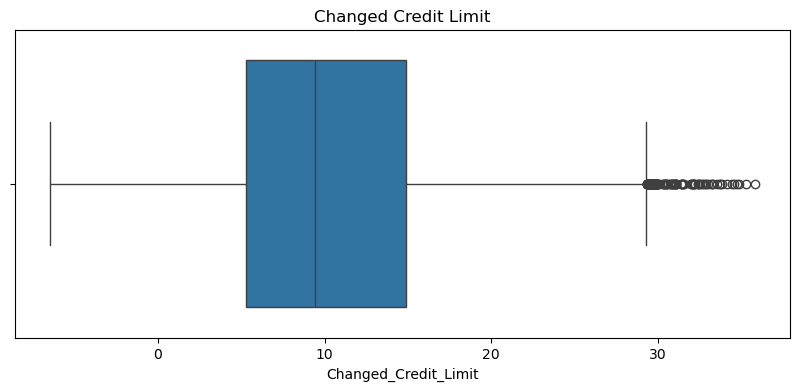

In [65]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["Changed_Credit_Limit"])
plt.title("Changed Credit Limit")
plt.show()

In [66]:
outlier, upper_changed_credit = filter_outlier(df, "Changed_Credit_Limit")

Jumlah outlier: 145
Upper Bound Changed_Credit_Limit: 29.32


In [ ]:
df['Changed_Credit_Limit'] = df.groupby('Customer_ID')['Changed_Credit_Limit'].ffill().bfill()
df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].fillna(df['Changed_Credit_Limit'].median())
df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].clip(lower=0) #Ada nilai -, clip nilai negatif ke 0

In [68]:
find_outlier(df, upper_changed_credit, "Changed_Credit_Limit")

Jumlah outlier: 148
Upper Bound Changed_Credit_Limit: 29.32


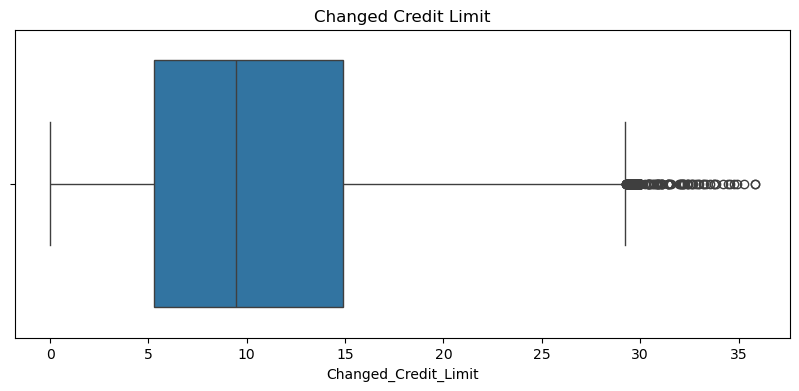

In [69]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["Changed_Credit_Limit"])
plt.title("Changed Credit Limit")
plt.show()

Faktor Menarik: 

Bahkan setelah imputasi group by customer, masih ada credit limit diatas upper bound 29.32%. Ini bukan merupakan anomali besar, perubahan kebijakan bank, mengajukan kenaikan limit ke bank, dan sebagainya dapat membuat credit limit terdeteksi berubah lebih dari 30%. Tentunya ini merupakan hal istimewa dan hanya 148 orang dari 25rb orang menjadi outliernya. Ini bukanlah hal yang mustahil terjadi dan wajar saja.

In [70]:
df[num_cols].columns

Index(['Unnamed: 0', 'Age', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance',
       'Credit_History_Age_Months', 'loan_unknown', 'loan_payday_loan',
       'loan_credit_builder_loan', 'loan_not_specified', 'loan_personal_loan',
       'loan_student_loan', 'loan_debt_consolidation_loan',
       'loan_home_equity_loan', 'loan_mortgage_loan', 'loan_auto_loan',
       'Loan_Count'],
      dtype='object')

In [71]:
df[num_cols].isna().sum()

Unnamed: 0                         0
Age                                0
Annual_Income                      0
Monthly_Inhand_Salary              0
Num_Bank_Accounts                  0
Num_Credit_Card                    0
Interest_Rate                      0
Num_of_Loan                     1204
Delay_from_due_date                0
Num_of_Delayed_Payment          1792
Changed_Credit_Limit               0
Num_Credit_Inquiries             472
Outstanding_Debt                 270
Credit_Utilization_Ratio           0
Total_EMI_per_month                0
Amount_invested_monthly         2183
Monthly_Balance                  301
Credit_History_Age_Months       2240
loan_unknown                       0
loan_payday_loan                   0
loan_credit_builder_loan           0
loan_not_specified                 0
loan_personal_loan                 0
loan_student_loan                  0
loan_debt_consolidation_loan       0
loan_home_equity_loan              0
loan_mortgage_loan                 0
l

##### C.3.7 Num_of_Loan & Num_of_Delayed_Payment

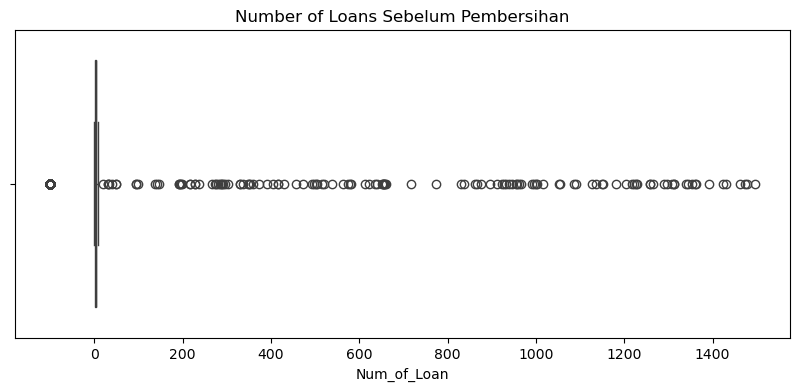

In [72]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Num_of_Loan'])
plt.title("Number of Loans Sebelum Pembersihan")
plt.show()

In [ ]:
# Batasi nilai bawah ke 0 karena jumlah pinjaman/telat bayar tidak bisa negatif
df['Num_of_Loan'] = df['Num_of_Loan'].clip(lower=0)
df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].clip(lower=0)

# Sisa NaN diisi 0 (asumsi paling aman)
df['Num_of_Loan'] = df['Num_of_Loan'].fillna(0)
df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].fillna(0)

outliers, upper_loan = filter_outlier(df, "Num_of_Loan")
outliers, upper_delayed = filter_outlier(df, "Num_of_Delayed_Payment")

# Imputasi berbasis upper
df['Num_of_Loan'] = df['Num_of_Loan'].clip(upper=upper_loan)
df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].clip(upper=upper_delayed)

find_outlier(df, upper_loan, "Num_of_Loan")
find_outlier(df, upper_delayed, "Num_of_Delayed_Payment")

Jumlah outlier: 127
Upper Bound Num_of_Loan: 11.00
Jumlah outlier: 176
Upper Bound Num_of_Delayed_Payment: 33.00
Jumlah outlier: 0
Upper Bound Num_of_Loan: 11.00
Jumlah outlier: 0
Upper Bound Num_of_Delayed_Payment: 33.00


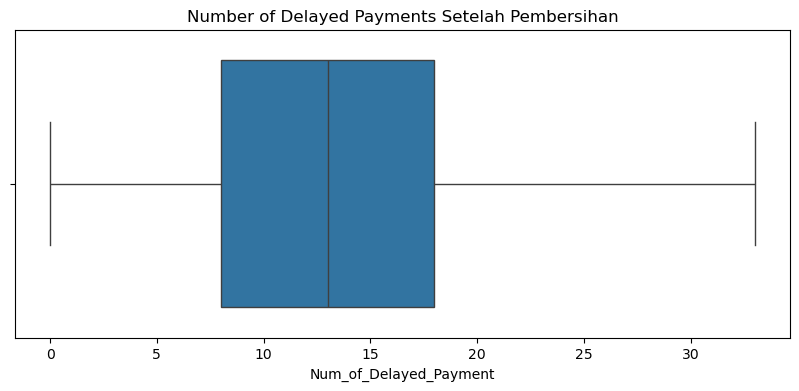

In [74]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Num_of_Delayed_Payment'])
plt.title("Number of Delayed Payments Setelah Pembersihan")
plt.show()

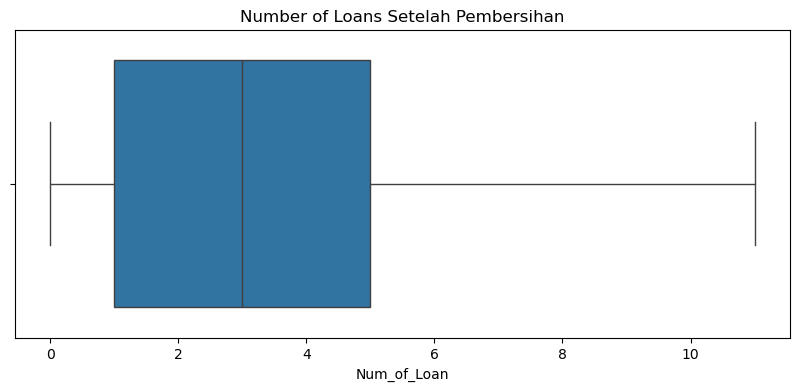

In [75]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Num_of_Loan'])
plt.title("Number of Loans Setelah Pembersihan")
plt.show()

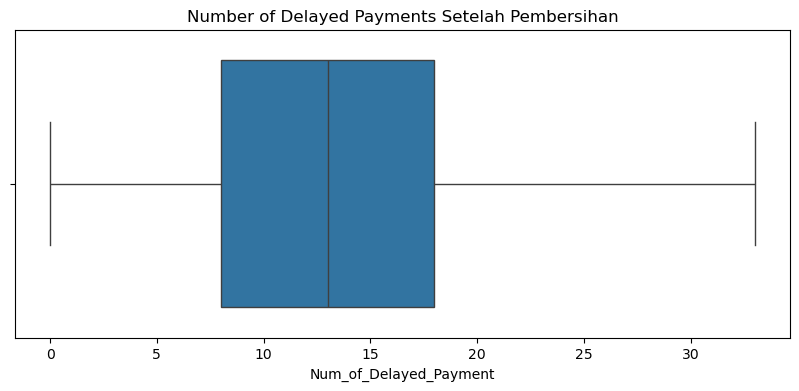

In [76]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Num_of_Delayed_Payment'])
plt.title("Number of Delayed Payments Setelah Pembersihan")
plt.show()

##### C.3.8 Num_Credit_Inquiries

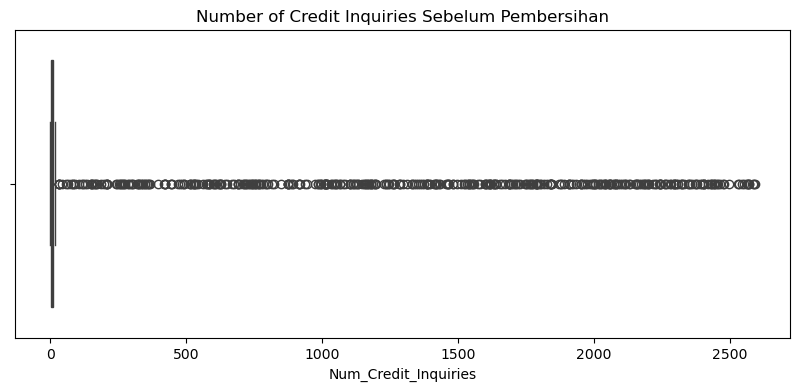

In [77]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Num_Credit_Inquiries'])
plt.title("Number of Credit Inquiries Sebelum Pembersihan")
plt.show()

In [78]:
outliers, upper_inquiries = filter_outlier(df, "Num_Credit_Inquiries")

df['Num_Credit_Inquiries'] = df['Num_Credit_Inquiries'].clip(lower=0)
df['Num_Credit_Inquiries'] = df[df['Num_Credit_Inquiries'] <= upper_inquiries]['Num_Credit_Inquiries'].fillna(0)
df['Num_Credit_Inquiries'] = df["Num_Credit_Inquiries"].fillna(0)

find_outlier(df, upper_inquiries, "Num_Credit_Inquiries")

Jumlah outlier: 417
Upper Bound Num_Credit_Inquiries: 18.00
Jumlah outlier: 0
Upper Bound Num_Credit_Inquiries: 18.00


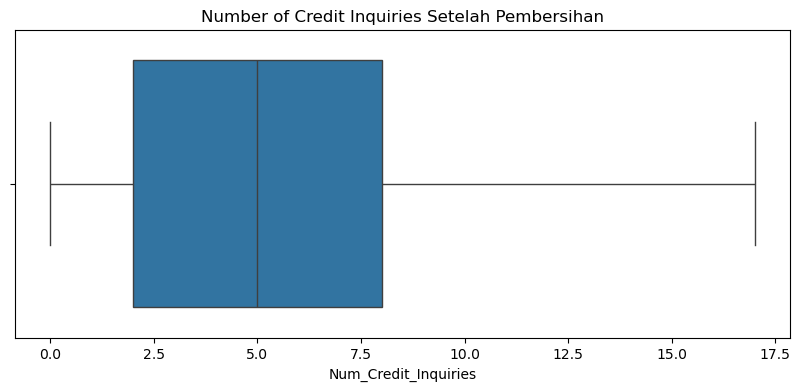

In [79]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Num_Credit_Inquiries'])
plt.title("Number of Credit Inquiries Setelah Pembersihan")
plt.show()

##### C.3.8 Outstanding Debt

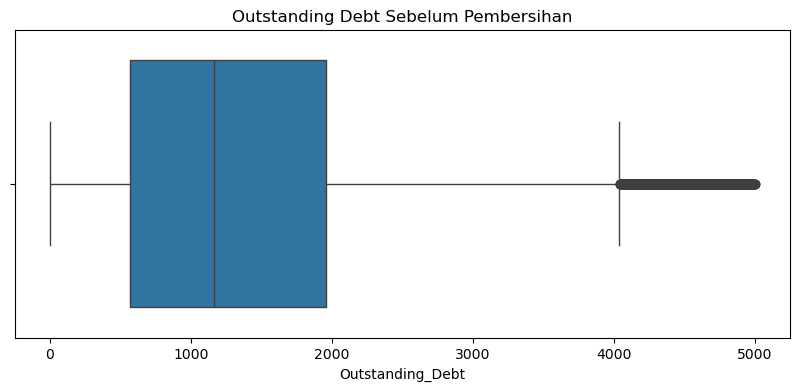

In [80]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Outstanding_Debt'])
plt.title("Outstanding Debt Sebelum Pembersihan")
plt.show()

In [81]:
df["Outstanding_Debt"].describe()

count    24730.000000
mean      1429.206300
std       1158.793138
min          0.340000
25%        568.595000
50%       1163.470000
75%       1956.107500
max       4997.100000
Name: Outstanding_Debt, dtype: float64

In [82]:
df["Outstanding_Debt"].isna().sum()

np.int64(270)

In [83]:
(df["Outstanding_Debt"] < 0).sum()

np.int64(0)

In [84]:
df["Outstanding_Debt"] = df["Outstanding_Debt"].clip(lower=0)
df["Outstanding_Debt"] = df.groupby('Customer_ID')['Outstanding_Debt'].ffill().bfill()
df["Outstanding_Debt"] = df["Outstanding_Debt"].fillna(0)

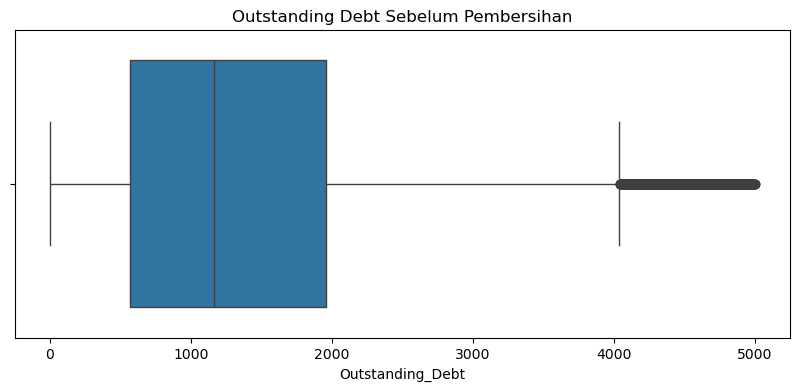

In [85]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Outstanding_Debt'])
plt.title("Outstanding Debt Sebelum Pembersihan")
plt.show()

##### C.3.9 Amount_invested_monthly

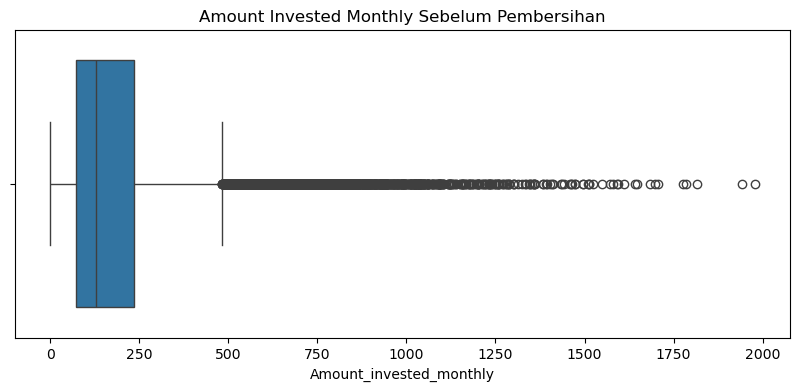

In [86]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Amount_invested_monthly'])
plt.title("Amount Invested Monthly Sebelum Pembersihan")
plt.show()

In [87]:
df["Amount_invested_monthly"] = df["Amount_invested_monthly"].clip(lower=0)
df["Amount_invested_monthly"] = df.groupby('Customer_ID')['Amount_invested_monthly'].ffill().bfill()
df["Amount_invested_monthly"] = df["Amount_invested_monthly"].fillna(0)

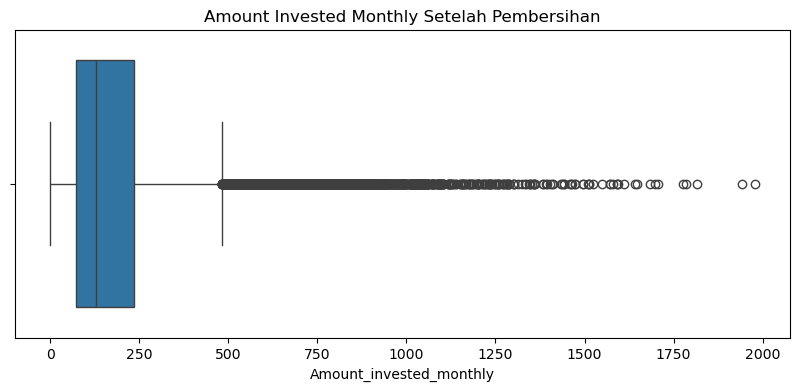

In [88]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Amount_invested_monthly'])
plt.title("Amount Invested Monthly Setelah Pembersihan")
plt.show()

##### C.3.10 Monthly Balance

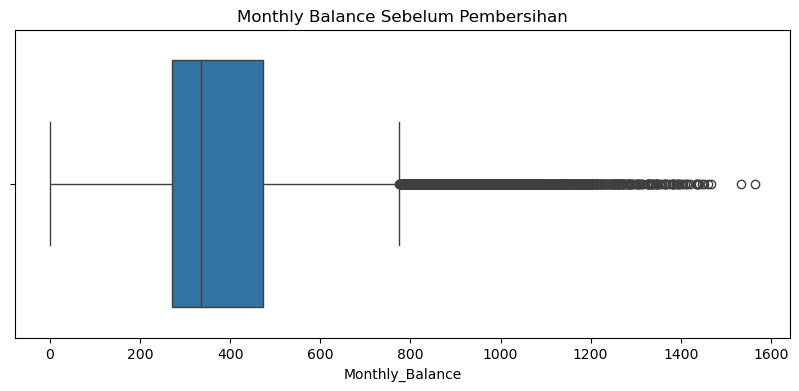

In [89]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Monthly_Balance'])
plt.title("Monthly Balance Sebelum Pembersihan")
plt.show()

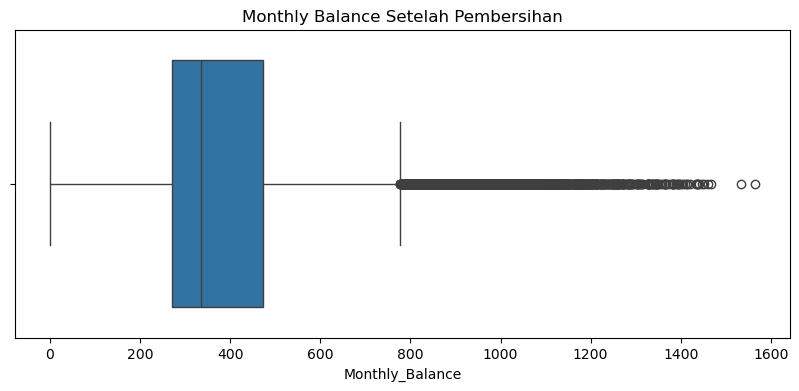

In [90]:
df["Monthly_Balance"] = df["Monthly_Balance"].clip(lower=0)
df["Monthly_Balance"] = df.groupby('Customer_ID')['Monthly_Balance'].ffill().bfill()
df["Monthly_Balance"] = df["Monthly_Balance"].fillna(0)

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Monthly_Balance'])
plt.title("Monthly Balance Setelah Pembersihan")
plt.show()

##### C.3.11 Credit_History_Age_Months

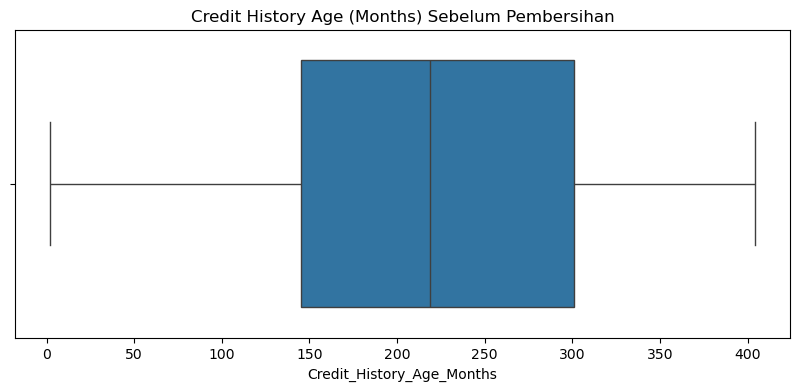

In [91]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["Credit_History_Age_Months"])
plt.title("Credit History Age (Months) Sebelum Pembersihan")
plt.show()

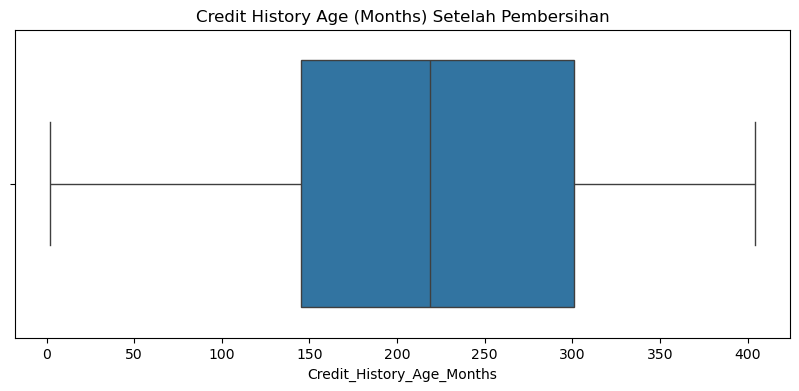

In [92]:
df["Credit_History_Age_Months"] = df["Credit_History_Age_Months"].clip(lower=0)
df["Credit_History_Age_Months"] = df.groupby('Customer_ID')['Credit_History_Age_Months'].ffill().bfill()
df["Credit_History_Age_Months"] = df["Credit_History_Age_Months"].fillna(0)

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Credit_History_Age_Months'])
plt.title("Credit History Age (Months) Setelah Pembersihan")
plt.show()

#### C.4 Final Look

In [93]:
df[cat_cols].isna().sum()

ID                                 0
Customer_ID                        0
Month                              0
Name                            2430
SSN                                0
Occupation                         0
Type_of_Loan                    2852
Credit_Mix                         0
Payment_of_Min_Amount              0
Credit_Score                       0
Spending_Level                     0
Payment_Size                       0
Loan_Auto_Loan                     0
Loan_Credit_Builder_Loan           0
Loan_Debt_Consolidation_Loan       0
Loan_Home_Equity_Loan              0
Loan_Mortgage_Loan                 0
Loan_Not_Specified                 0
Loan_Payday_Loan                   0
Loan_Personal_Loan                 0
Loan_Student_Loan                  0
dtype: int64

In [203]:
df[num_cols].isna().sum()

Unnamed: 0                      0
Age                             0
Annual_Income                   0
Monthly_Inhand_Salary           0
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Delay_from_due_date             0
Num_of_Delayed_Payment          0
Changed_Credit_Limit            0
Num_Credit_Inquiries            0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Total_EMI_per_month             0
Amount_invested_monthly         0
Monthly_Balance                 0
Credit_History_Age_Months       0
loan_unknown                    0
loan_payday_loan                0
loan_credit_builder_loan        0
loan_not_specified              0
loan_personal_loan              0
loan_student_loan               0
loan_debt_consolidation_loan    0
loan_home_equity_loan           0
loan_mortgage_loan              0
loan_auto_loan                  0
Loan_Count                      0
dtype: int64

In [204]:
df.duplicated().sum()

np.int64(0)

Text(0.5, 1.0, 'Correlation Matrix')

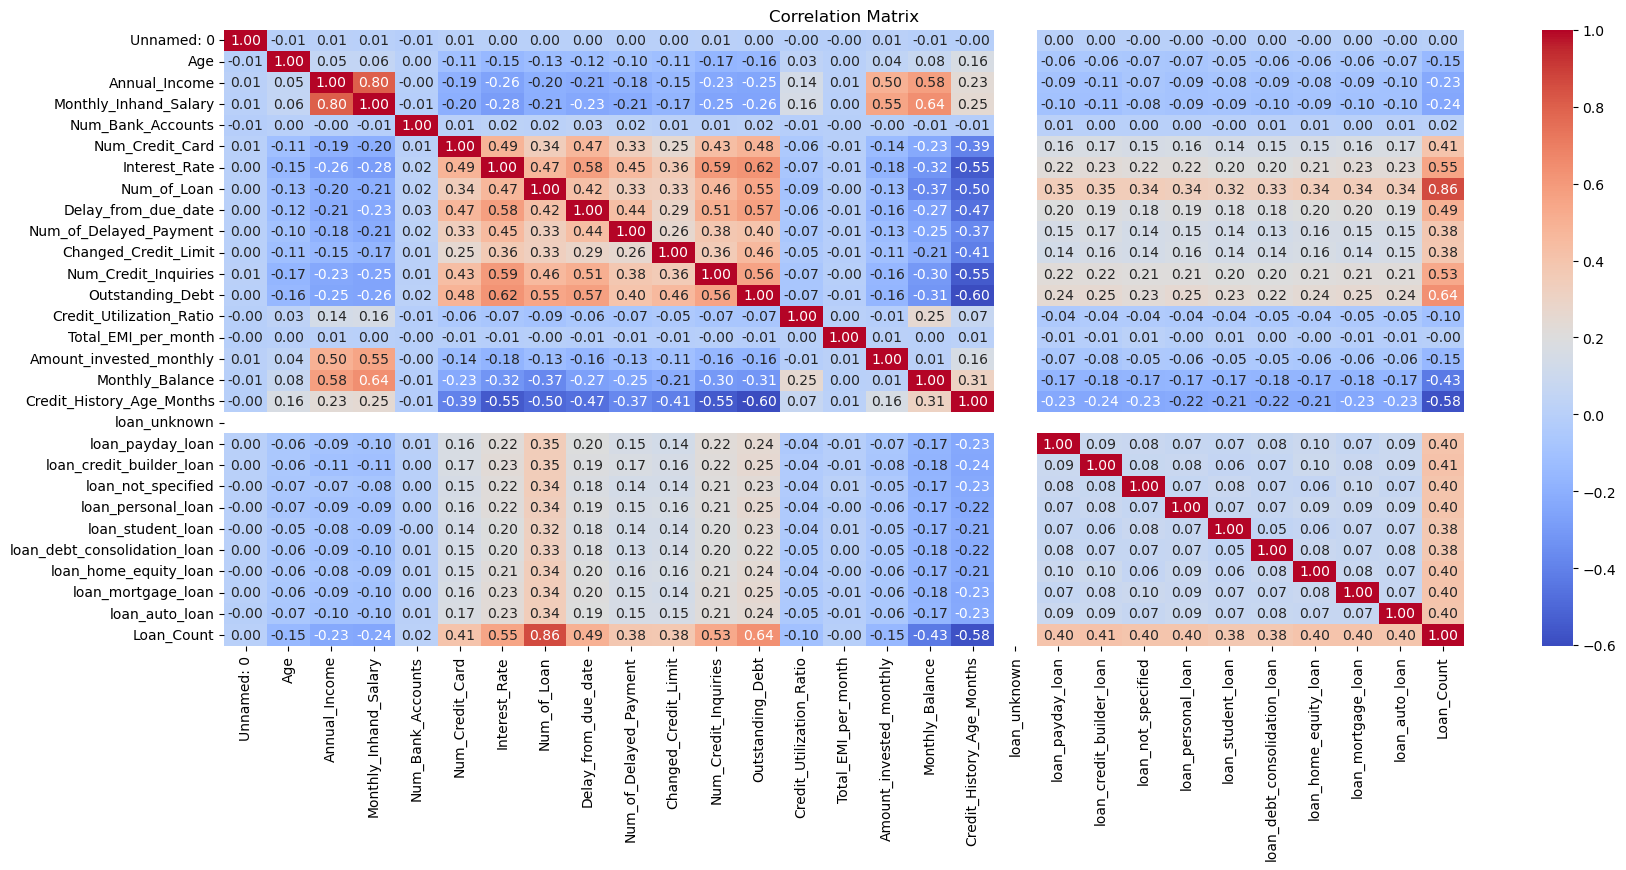

In [205]:
plt.figure(figsize=(20, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")

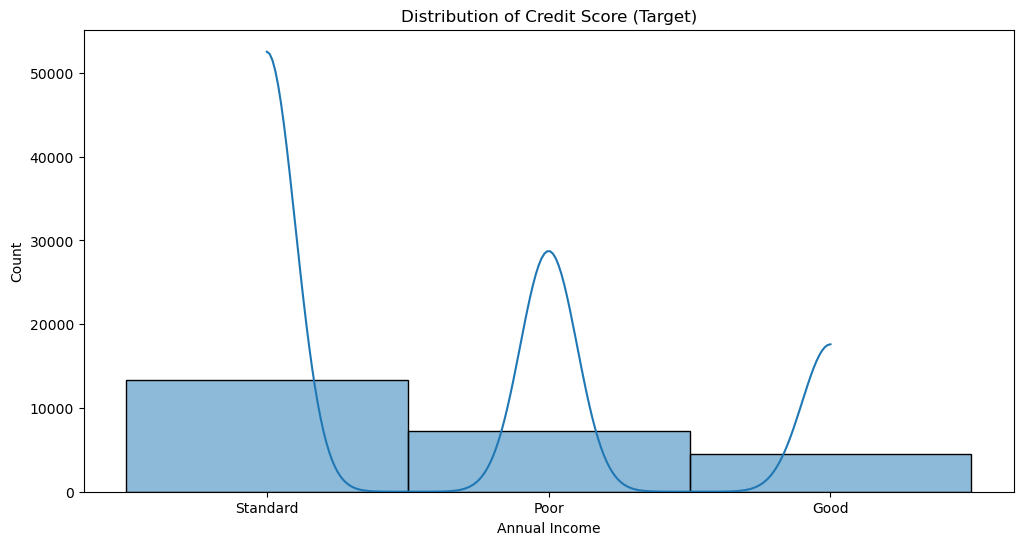

In [206]:
plt.figure(figsize=(12, 6))
sns.histplot(df["Credit_Score"], kde=True)

plt.title("Distribution of Credit Score (Target)")
plt.xlabel("Annual Income")
plt.ylabel("Count")
plt.show()

### D. Preprocessing

#### D.1 Handling Final Categorical Problem

In [207]:
df[cat_cols].columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'SSN', 'Occupation',
       'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Credit_Score',
       'Spending_Level', 'Payment_Size', 'Loan_Auto_Loan',
       'Loan_Credit_Builder_Loan', 'Loan_Debt_Consolidation_Loan',
       'Loan_Home_Equity_Loan', 'Loan_Mortgage_Loan', 'Loan_Not_Specified',
       'Loan_Payday_Loan', 'Loan_Personal_Loan', 'Loan_Student_Loan'],
      dtype='object')

In [208]:
df = df.drop(columns=['Unnamed: 0', 'ID', 'Customer_ID', 'Name', 'SSN', "Type_of_Loan"], errors='ignore')

cat_cols = df.select_dtypes(exclude=["float", "int"]).columns

In [209]:
df[cat_cols].columns

Index(['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Credit_Score', 'Spending_Level', 'Payment_Size', 'Loan_Auto_Loan',
       'Loan_Credit_Builder_Loan', 'Loan_Debt_Consolidation_Loan',
       'Loan_Home_Equity_Loan', 'Loan_Mortgage_Loan', 'Loan_Not_Specified',
       'Loan_Payday_Loan', 'Loan_Personal_Loan', 'Loan_Student_Loan'],
      dtype='object')

Encoding Categorical

In [210]:
df["Occupation"].value_counts()

Occupation
Unknown          1765
Lawyer           1642
Mechanic         1621
Teacher          1618
Developer        1580
Journalist       1568
Scientist        1558
Accountant       1553
Media_Manager    1552
Architect        1550
Engineer         1549
Entrepreneur     1511
Doctor           1504
Manager          1497
Musician         1491
Writer           1441
Name: count, dtype: int64

In [211]:
df[cat_cols].head(2)

,Month,Occupation,Credit_Mix,Payment_of_Min_Amount,Credit_Score,Spending_Level,Payment_Size,Loan_Auto_Loan,Loan_Credit_Builder_Loan,Loan_Debt_Consolidation_Loan,Loan_Home_Equity_Loan,Loan_Mortgage_Loan,Loan_Not_Specified,Loan_Payday_Loan,Loan_Personal_Loan,Loan_Student_Loan
0,August,Journalist,Standard,Yes,Standard,High_spent,Small,0,0,0,0,1,0,0,1,1
1,August,Teacher,Standard,Yes,Poor,Low_spent,Medium,0,0,0,0,0,0,0,1,1


One Hot Encoding for Occupation Column

Ordinal Encoding untuk kolom yang urutan (Date, dan kolom good/bad)

#### D.2. Implementing OOP Preprocessing

In [212]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder, OneHotEncoder, MultiLabelBinarizer


Update CreditDataPreprocessor:

In [ ]:
class CreditDataCleaning:
    def __init__(self, csv_path, target_column): #Method yang secara otomatis dibuat jika membuat objek
        self.file_path = csv_path #instance
        self.target_column = target_column #instance
        self.df = None #instance
        self.outlier_bounds = {} #instance
        
    def load_data(self): #buat metode baca data
        """Membaca dataset dari path"""
        self.df = pd.read_csv(self.file_path, low_memory=False)
        print(f"Data is loaded successfully from '{self.file_path}'.")
        return self.df

    def filter_outlier(self, df, column): #Metode filter outlier
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[df[column] > upper_bound]
        return outliers, upper_bound

    def check_outlier(self, upper_bound, column): #Metode Check Outlier
        outliers = self.df[self.df[column] > upper_bound]
        print(f"Jumlah outlier: {len(outliers)} | Upper Bound {column}: {upper_bound:.2f}")

    def cast_categorical_to_numeric(self): #Method casting data
        self.df["Age"] = pd.to_numeric(self.df["Age"], errors="coerce")
        self.df["Annual_Income"] = pd.to_numeric(self.df["Annual_Income"], errors="coerce")
        self.df["Num_of_Loan"] = pd.to_numeric(self.df["Num_of_Loan"], errors="coerce")
        self.df["Num_of_Delayed_Payment"] = self.df["Num_of_Delayed_Payment"].astype(str).str.replace(r"[^\d]", "", regex=True)
        self.df["Num_of_Delayed_Payment"] = pd.to_numeric(self.df["Num_of_Delayed_Payment"], errors="coerce")
        self.df["Changed_Credit_Limit"] = pd.to_numeric(self.df["Changed_Credit_Limit"], errors="coerce")
        self.df["Outstanding_Debt"] = pd.to_numeric(self.df["Outstanding_Debt"], errors="coerce")
        self.df["Amount_invested_monthly"] = pd.to_numeric(self.df["Amount_invested_monthly"], errors="coerce")

        return self.df

    def history_to_months(self, x): #Method untuk konversi tahun dan bulan menjadi total bulan
        if pd.isna(x):
            return np.nan
        match = re.search(r"(\d+)\s+Years?\s+and\s+(\d+)\s+Months?", str(x))

        if match:
            years = int(match.group(1))
            months = int(match.group(2))
            return years * 12 + months
        
        return np.nan

    def count_loans(self, x): #Metode Hitung jumlah loan
        if pd.isna(x):
            return 0
        loans = x.replace(" and ", ", ").split(",")
        return len([loan.strip() for loan in loans if loan.strip()])


    def fix_numerical_outliers(self, ver): #Method Fix numerical column seperti sebelumnya
        self.outlier_bounds = {}

        # Fix Age
        self.df.loc[(self.df['Age'] < 18) | (self.df['Age'] > 100), 'Age'] = np.nan
        self.df['Age'] = self.df.groupby("Customer_ID")["Age"].ffill().bfill()
        self.df['Age'] = self.df['Age'].fillna(self.df['Age'].median())

        # Fix Annual Income
        self.df.loc[self.df['Annual_Income'] > 300000, 'Annual_Income'] = np.nan
        _, upper_annual = self.filter_outlier(self.df, "Annual_Income")
        self.outlier_bounds["Annual_Income"] = upper_annual
        self.df.loc[self.df['Annual_Income'] > upper_annual, 'Annual_Income'] = np.nan
        self.df['Annual_Income'] = self.df.groupby('Occupation')['Annual_Income'].transform(lambda x: x.fillna(x.median()))

        # Fix Interest Rate
        _, upper_interest = self.filter_outlier(self.df, "Interest_Rate")
        self.outlier_bounds["Interest_Rate"] = upper_interest
        self.df.loc[self.df['Interest_Rate'] > upper_interest, 'Interest_Rate'] = np.nan
        self.df['Interest_Rate'] = self.df.groupby('Customer_ID')['Interest_Rate'].ffill().bfill()
        self.df['Interest_Rate'] = self.df['Interest_Rate'].fillna(self.df['Interest_Rate'].median())

        # Fix Monthly Inhand Salary
        self.df['Monthly_Inhand_Salary'] = self.df.groupby('Customer_ID')['Monthly_Inhand_Salary'].ffill().bfill()
        self.df['Monthly_Inhand_Salary'] = self.df.groupby('Occupation')['Monthly_Inhand_Salary'].transform(lambda x: x.fillna(x.median()))
        _, upper_salary = self.filter_outlier(self.df, "Monthly_Inhand_Salary")
        self.outlier_bounds["Monthly_Inhand_Salary"] = upper_salary
        self.df['Monthly_Inhand_Salary'] = self.df['Monthly_Inhand_Salary'].clip(upper=upper_salary)

        # Fix Number of Credit Card
        _, upper_credit = self.filter_outlier(self.df, "Num_Credit_Card")
        self.outlier_bounds["Num_Credit_Card"] = upper_credit
        self.df.loc[self.df['Num_Credit_Card'] > 12, 'Num_Credit_Card'] = np.nan
        self.df['Num_Credit_Card'] = self.df.groupby('Customer_ID')['Num_Credit_Card'].ffill().bfill()
        self.df['Num_Credit_Card'] = self.df['Num_Credit_Card'].fillna(self.df['Num_Credit_Card'].median())
        self.df['Num_Credit_Card'] = self.df['Num_Credit_Card'].clip(upper=11)

        # Fix Delay from Due Date
        self.df['Delay_from_due_date'] = self.df['Delay_from_due_date'].clip(lower=0)
        self.df['Delay_from_due_date'] = self.df.groupby('Customer_ID')['Delay_from_due_date'].ffill().bfill()
        self.df['Delay_from_due_date'] = self.df['Delay_from_due_date'].fillna(self.df['Delay_from_due_date'].median())

        # Fix Changed Credit Limit
        self.df['Changed_Credit_Limit'] = self.df.groupby('Customer_ID')['Changed_Credit_Limit'].ffill().bfill()
        self.df['Changed_Credit_Limit'] = self.df['Changed_Credit_Limit'].fillna(self.df['Changed_Credit_Limit'].median())
        self.df['Changed_Credit_Limit'] = self.df['Changed_Credit_Limit'].clip(lower=0)


        # Fix Number of Loans and Delayed Payment
        self.df['Num_of_Loan'] = self.df['Num_of_Loan'].clip(lower=0)
        self.df['Num_of_Delayed_Payment'] = self.df['Num_of_Delayed_Payment'].clip(lower=0)
        self.df['Num_of_Loan'] = self.df.groupby('Customer_ID')['Num_of_Loan'].ffill().bfill()
        self.df['Num_of_Delayed_Payment'] = self.df.groupby('Customer_ID')['Num_of_Delayed_Payment'].ffill().bfill()
        self.df['Num_of_Loan'] = self.df['Num_of_Loan'].fillna(0)
        self.df['Num_of_Delayed_Payment'] = self.df['Num_of_Delayed_Payment'].fillna(0)

        _, upper_bound_loan = self.filter_outlier(self.df, "Num_of_Loan")
        _, upper_bound_delayed = self.filter_outlier(self.df, "Num_of_Delayed_Payment")
        self.outlier_bounds["Num_of_Loan"] = upper_bound_loan
        self.outlier_bounds["Num_of_Delayed_Payment"] = upper_bound_delayed

        self.df['Num_of_Loan'] = self.df['Num_of_Loan'].clip(upper=upper_bound_loan)
        self.df['Num_of_Delayed_Payment'] = self.df['Num_of_Delayed_Payment'].clip(upper=upper_bound_delayed)

        # Fix Number of Credit Inquiries
        self.df['Num_Credit_Inquiries'] = self.df['Num_Credit_Inquiries'].clip(lower=0)
        self.df['Num_Credit_Inquiries'] = self.df.groupby('Customer_ID')['Num_Credit_Inquiries'].ffill().bfill()
        self.df['Num_Credit_Inquiries'] = self.df['Num_Credit_Inquiries'].fillna(0)
        _, upper_bound_inquiries = self.filter_outlier(self.df, "Num_Credit_Inquiries")
        self.outlier_bounds["Num_Credit_Inquiries"] = upper_bound_inquiries
        self.df['Num_Credit_Inquiries'] = self.df['Num_Credit_Inquiries'].clip(upper=upper_bound_inquiries)

        # Fix Outstanding Debt
        self.df["Outstanding_Debt"] = self.df["Outstanding_Debt"].clip(lower=0)
        self.df["Outstanding_Debt"] = self.df.groupby('Customer_ID')['Outstanding_Debt'].ffill().bfill()
        self.df["Outstanding_Debt"] = self.df["Outstanding_Debt"].fillna(0)

        # Fix Amount Invested Monthly
        self.df["Amount_invested_monthly"] = self.df["Amount_invested_monthly"].clip(lower=0)
        self.df["Amount_invested_monthly"] = self.df.groupby('Customer_ID')['Amount_invested_monthly'].ffill().bfill()
        self.df["Amount_invested_monthly"] = self.df["Amount_invested_monthly"].fillna(0)

        # Fix Monthly Balance
        self.df["Monthly_Balance"] = self.df["Monthly_Balance"].clip(lower=0)
        self.df["Monthly_Balance"] = self.df.groupby('Customer_ID')['Monthly_Balance'].ffill().bfill()
        self.df["Monthly_Balance"] = self.df["Monthly_Balance"].fillna(0)

        # Fix Credit History Age Months

        self.df["Credit_History_Age_Months"] = self.df["Credit_History_Age"].apply(self.history_to_months)
        self.df["Credit_History_Age_Months"] = self.df["Credit_History_Age_Months"].clip(lower=0)
        self.df["Credit_History_Age_Months"] = self.df.groupby('Customer_ID')['Credit_History_Age_Months'].ffill().bfill()
        self.df["Credit_History_Age_Months"] = self.df["Credit_History_Age_Months"].fillna(self.df["Credit_History_Age_Months"].median())

        # --- Verifikasi Bebas Outlier Ekstrem ---
        if(ver == 1):
            print("\n=== Check Outliers Post-Processing ===")
            for column, upper_b in self.outlier_bounds.items():
                self.check_outlier(upper_b, column)

            print("Outlier handling is completed.")
        return self.df

   
    def handle_categorical_columns(self): #Metode cleaning categorical column
       
        # Fixing Missing Value in Categorical
        self.df["Occupation"] = self.df["Occupation"].replace("_______", "Unknown").fillna("Unknown")
        self.df["Credit_Mix"] = self.df["Credit_Mix"].replace("_", "Unknown").fillna("Unknown")
       
        # Feature Extraction dari Payment Behaviour
        self.df["Spending_Level"] = self.df["Payment_Behaviour"].str.extract(r"(High_spent|Low_spent)").fillna("Unknown")
        self.df["Payment_Size"] = self.df["Payment_Behaviour"].str.extract(r"(Small|Medium|Large)").fillna("Unknown")

        # MultiLabelBinarizer untuk Type_of_Loan
        self.df["Loan_Count"] = self.df["Type_of_Loan"].apply(self.count_loans)
        loan_lists = self.df["Type_of_Loan"].fillna("").str.replace(" and ", ", ", regex=False).str.split(",")
        loan_lists = loan_lists.apply(lambda x: [i.strip() for i in x if i.strip()])
       
        mlb = MultiLabelBinarizer()
        loan_binary_array = mlb.fit_transform(loan_lists)
        columns_with_prefix = [f"Loan_{c.replace(' ', '_').replace('-', '_')}" for c in mlb.classes_]
        loan_df = pd.DataFrame(loan_binary_array, columns=columns_with_prefix, index=self.df.index).astype(np.int8)
        self.df = pd.concat([self.df, loan_df], axis=1)

        return self.df

    def finalize_dataframe(self): #Metode membuang kolom yang sudah tidak digunakan untuk cleaning akhir 
        drop_cols = ['Unnamed: 0', 'ID', 'Customer_ID', 'Name', 'SSN', 'Type_of_Loan', 'Payment_Behaviour', 'Credit_History_Age', 'Loan_Unknown', 'loan_unknown']
        self.df = self.df.drop(columns=[col for col in drop_cols if col in self.df.columns], errors='ignore')
        return self.df

    def final_check_df(self, ver = 0): #Metode check semua anomali
        cat_cols = self.df.select_dtypes(include=["object"]).columns
        num_cols = self.df.select_dtypes(include=["float64", "int64", "int32", "int8"]).columns

        if (ver == 1):
            print("\n=== Final Check Dataframe ===")
            if len(cat_cols) > 0:
                display(self.df[cat_cols].describe())
            display(self.df[num_cols].describe())
            print("Missing Values Summary:")
            print(self.df.isna().sum())

    def run_all_cleaner(self, ver): #Orchestrasi (Abstraction, User tinggal menjalankan metode ini untuk seluruh logika rumit)
        print("Starting Preprocessing Pipeline...") #Konsep Encapsulation supaya metode pembersihan 
        self.load_data()                            #dan perbaikan kolom tidak berserakan tanpa tujuan
        self.cast_categorical_to_numeric()
        self.fix_numerical_outliers(ver)
        self.handle_categorical_columns()
        self.finalize_dataframe()
       
        self.final_check_df(ver)
        print("\nPipeline executed successfully! Data is ready for splitting/modeling.")

        return self.df


In [ ]:
class UnifiedCreditPreprocessor(CreditDataCleaning): #Inheritence, kelas ini dapat mengakses metode dan atribut di kelas CreditDataCleaning
    def __init__(self, csv_path, target_column):
        super().__init__(csv_path, target_column) #Panggil fungsi dan konstruktur di parent class
        self.X_train, self.X_test, self.y_train, self.y_test = [None] * 4

    def encode_categorical_features(self):
        # 1. Custom Ordinal Encoding
        credit_mix_map = {'Bad': 0, 'Unknown': 1, 'Standard': 2, 'Good': 3}
        spending_map = {'Low_spent': 0, 'Unknown': 1, 'High_spent': 2}
        payment_size_map = {'Small': 0, 'Unknown': 1, 'Medium': 2, 'Large': 3}

        self.df['Credit_Mix'] = self.df['Credit_Mix'].map(credit_mix_map).fillna(1)
        self.df['Spending_Level'] = self.df['Spending_Level'].map(spending_map).fillna(1)
        self.df['Payment_Size'] = self.df['Payment_Size'].map(payment_size_map).fillna(1)

        if 'Payment_of_Min_Amount' in self.df.columns:
            self.df['Payment_of_Min_Amount'] = self.df['Payment_of_Min_Amount'].str.strip().map({'Yes': 1, 'No': 0}).fillna(0.5)

        Month_map = {'January': 0, "Febuary": 1, "March": 2, "April": 3, "May": 4, "June": 5, "July": 6, "August": 7,
                     "September": 8, "October": 9, "November": 10, "December": 11}
        self.df['Month'] = self.df['Month'].map(Month_map).fillna(1)
       
        # 2. Custom One-Hot Encoding untuk Occupation
        if 'Occupation' in self.df.columns:
            self.df = pd.get_dummies(self.df, columns=['Occupation'], prefix='Occ', drop_first=True, dtype=int)

        # Target Variable Mapping
        if self.target_column in self.df.columns:
            score_map = {'Poor': 0, 'Standard': 1, 'Good': 2}
            self.df[self.target_column] = self.df[self.target_column].map(score_map)
        return self.df
    
    def split_data(self, test_size=0.2, random_state=42):
        X = self.df.drop(columns=[self.target_column])
        y = self.df[self.target_column]

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )

        print(f"\nData split into training and testing sets with test size = {test_size}.")
        print(f"X_train set: {self.X_train.shape} | X_test set: {self.X_test.shape}")

        self.X_train, self.X_test = self.normalize_data()
        return self.X_train, self.X_test, self.y_train, self.y_test
    
    def normalize_data(self):
        scaler = StandardScaler()

        self.X_train_scaled = scaler.fit_transform(self.X_train)
        self.X_test_scaled = scaler.transform(self.X_test)
        return self.X_train_scaled, self.X_test_scaled


    def fit(self, csv_path, target_column, ver):  #Polymorphism gaya scikit-learn
        self.df = self.run_all_cleaner(ver)
        return self.df

    def fit_transform(self, test_size=0.2, random_state=42):
        self.df = self.encode_categorical_features()

        return self.split_data(test_size=test_size, random_state=random_state)

#### D.3. Full Preprocessing Orchestratation

In [215]:
csv_path = Path("../data/raw/data_C.csv")
target_column = "Credit_Score"
preprocessor = UnifiedCreditPreprocessor(csv_path, target_column)

df_cleaned = preprocessor.fit(csv_path, target_column, 1)
X_train, X_test, y_train, y_test = preprocessor.fit_transform(0.2, 42)

Starting Preprocessing Pipeline...
Data is loaded successfully from '..\data\raw\data_C.csv'.

=== Check Outliers Post-Processing ===
Jumlah outlier: 0 | Upper Bound Annual_Income: 150260.17
Jumlah outlier: 0 | Upper Bound Interest_Rate: 38.00
Jumlah outlier: 0 | Upper Bound Monthly_Inhand_Salary: 12430.58
Jumlah outlier: 0 | Upper Bound Num_Credit_Card: 11.50
Jumlah outlier: 0 | Upper Bound Num_of_Loan: 11.00
Jumlah outlier: 0 | Upper Bound Num_of_Delayed_Payment: 31.50
Jumlah outlier: 0 | Upper Bound Num_Credit_Inquiries: 18.00
Outlier handling is completed.

=== Final Check Dataframe ===


,Month,Occupation,Credit_Mix,Payment_of_Min_Amount,Credit_Score,Spending_Level,Payment_Size
count,25000,25000,25000,25000,25000,25000,25000
unique,8,16,4,3,3,3,4
top,February,Unknown,Standard,Yes,Standard,Low_spent,Small
freq,3203,1765,9170,13082,13282,12497,9158


,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,Loan_Count,Loan_Auto_Loan,Loan_Credit_Builder_Loan,Loan_Debt_Consolidation_Loan,Loan_Home_Equity_Loan,Loan_Mortgage_Loan,Loan_Not_Specified,Loan_Payday_Loan,Loan_Personal_Loan,Loan_Student_Loan
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000
mean,34.269760,46888.269338,4152.491273,18.075360,5.534560,14.518400,3.426840,20.999720,13.473980,10.425055,...,3.520600,0.305880,0.316040,0.311120,0.31188,0.312840,0.312640,0.322120,0.31416,0.311320
std,10.067985,33539.155326,3125.973162,122.375374,2.063729,8.759526,2.544977,14.834278,6.412948,6.736160,...,2.438092,0.460788,0.464938,0.462961,0.46327,0.463659,0.463578,0.467298,0.46419,0.463043
min,18.000000,7005.930000,303.645417,-1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,26.000000,19891.580000,1607.090000,3.000000,4.000000,7.000000,1.000000,10.000000,9.000000,5.300000,...,2.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000
50%,34.000000,36534.180000,3062.512500,6.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.430000,...,3.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000
75%,42.000000,65400.795000,5936.484583,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,14.872500,...,5.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.00000,1.000000
max,95.000000,150131.680000,12430.576458,1789.000000,11.000000,34.000000,11.000000,67.000000,31.500000,35.820000,...,9.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.00000,1.000000


Missing Values Summary:
Month                           0
Age                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary           0
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Delay_from_due_date             0
Num_of_Delayed_Payment          0
Changed_Credit_Limit            0
Num_Credit_Inquiries            0
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly         0
Monthly_Balance                 0
Credit_Score                    0
Credit_History_Age_Months       0
Spending_Level                  0
Payment_Size                    0
Loan_Count                      0
Loan_Auto_Loan                  0
Loan_Credit_Builder_Loan        0
Loan_Debt_Consolidation_Loan    0
Loan_Home_Equity_Loan   

In [217]:
X_train.columns

Index(['Month', 'Age', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Payment_of_Min_Amount',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance',
       'Credit_History_Age_Months', 'Spending_Level', 'Payment_Size',
       'Loan_Count', 'Loan_Auto_Loan', 'Loan_Credit_Builder_Loan',
       'Loan_Debt_Consolidation_Loan', 'Loan_Home_Equity_Loan',
       'Loan_Mortgage_Loan', 'Loan_Not_Specified', 'Loan_Payday_Loan',
       'Loan_Personal_Loan', 'Loan_Student_Loan', 'Occ_Architect',
       'Occ_Developer', 'Occ_Doctor', 'Occ_Engineer', 'Occ_Entrepreneur',
       'Occ_Journalist', 'Occ_Lawyer', 'Occ_Manager', 'Occ_Mechanic',
       'Occ_Media_Manager', 'Occ_Musician', 'Occ_Scientist', 'Occ_Teacher',
       'Occ_Unkn

### E. Modelling

#### E.1 Procedural Modelling to Decide which model best perform with this data

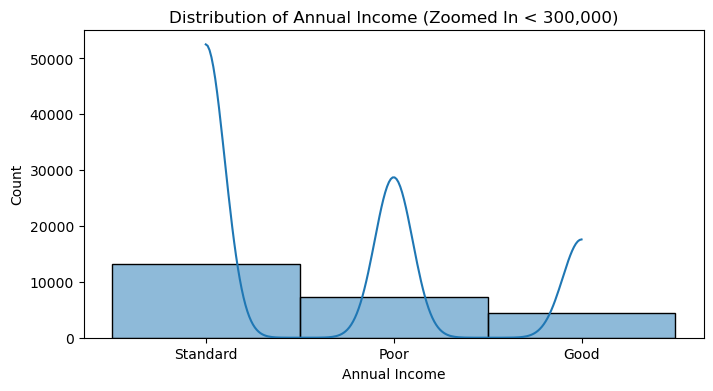

In [218]:
plt.figure(figsize=(8, 4))
sns.histplot(df["Credit_Score"], kde=True)

plt.title("Distribution of Annual Income (Zoomed In < 300,000)")
plt.xlabel("Annual Income")
plt.ylabel("Count")
plt.show()

**Target Modelling**:

Memilih model yang mampu prediksi kelas dengan tingkat terpengaruhi oleh kelas dominan sangat kecil.

Confusion Matrix:

[ ,x, y] -> Baris Asli Class 0 (Poor)

[ , , ]  -> Baris Asli Class 1 (Standard)

[ , , ] -> Baris Asli Class 2 (Good)

Case: Sebuah bank ingin menawarkan pinjaman kepada calon konsumen, Tugas kita adalah meminimalisir meminjamkan ke orang dengan kredit skor yang rendah.

x dan y pada baris asli kategori poor adalah angka kesalahan model dalam memprediksi orang yang poor namun dianggap sebagai standard(x) dan good(y) kredit skornya. Sehingga model memberikan orang orang berikut ini kredit padahal kredit skornya poor.

Kesalahan ini dapat mengakibatkan Non-performing-loan (NPL) / kredit macet. Kita harus prioritaskan angka x dan y serendah mungkin.

Pada saat yang sama, Bank membutuhkan calon nasabah yang taat aturan agar terus mendapat profit untuk mempertahankan keberlangsungan bisnis. Maka model kita juga perlu pintar menentukan kelas Good dengan benar sebagai nasabah premium bank. 

**Scoring: F1 (Mengandung Recall dan Precision) & Accuracy**

- F1 Standar: Memberi bobot adil antar precision dan recall dengan penggunaan yang sering di biner yang sama pentingnya
- F1 Macro: memberikan bobot yang sama ke setiap kelas, terlepas dari jumlah datanya
- F1 Micro: Menghitung total TP, FP, FN secara keseluruhan di semua kelas terlebih dahulu, lalu menghitung F1-nya.
- F1 Weighted: menghitung F1-Score untuk setiap kelas, lalu memberikan bobot berdasarkan jumlah sampel (support) masing-masing kelas.

Kita akan menggunakan Macro yang lebih objektif dan memaksa model menentukan semua kelas seakurat mungkin.






In [219]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.model_selection import StratifiedKFold, cross_validate

In [ ]:
# Gunakan CV KFold mencegah Overfitting dan memastikan model pintar secara general 
# (bukan karena faktor keberuntungan acak saat split data).
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['accuracy', 'f1_macro', 'f1_micro']

def cross_check(model, X_train, y_train, X_test, y_test):
        print("Running Stratified 5-Fold Cross Validation...")
        cv_results = cross_validate(
            model, X_train, y_train, 
            cv=skf, scoring=scoring, n_jobs=-1
        )

        y_pred = model.predict(X_test)
        
        print("\n" + "="*10 + " Final Test Set Evaluation " + "="*10)
        print(classification_report(y_test, y_pred))
        
        print("Confusion Matrix:")
        print(confusion_matrix(y_test, y_pred))

        print("\n" + "="*10 + " Cross Validation Results (Mean) " + "="*10)
        print(f"Mean CV Accuracy: {np.mean(cv_results['test_accuracy']):.4f} (+/- {np.std(cv_results['test_accuracy']):.4f})")
        print(f"Mean CV F1 Macro: {np.mean(cv_results['test_f1_macro']):.4f}")
        print(f"Mean CV F1 Micro : {np.mean(cv_results['test_f1_micro']):.4f}")

In [221]:
X_train.head(2)

,Month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Occ_Journalist,Occ_Lawyer,Occ_Manager,Occ_Mechanic,Occ_Media_Manager,Occ_Musician,Occ_Scientist,Occ_Teacher,Occ_Unknown,Occ_Writer
13869,2.0,19.0,61936.00,5018.333333,10,8.0,28.0,8.0,47,20.0,...,0,0,0,0,0,0,0,0,0,0
20687,2.0,22.0,102046.83,8609.902500,3,3.0,3.0,0.0,6,5.0,...,0,0,0,0,0,0,0,0,0,0


In [222]:
rfr = RandomForestClassifier(n_estimators=200, class_weight="balanced_subsample",random_state=42, n_jobs=-1)
rfr.fit(X_train, y_train)
print("Random Forest Result:")
rfr_score = cross_check(rfr, X_train, y_train, X_test, y_test)

Random Forest Result:
Running Stratified 5-Fold Cross Validation...

========== Final Test Set Evaluation ==========
              precision    recall  f1-score   support

           0       0.77      0.72      0.74      1454
           1       0.75      0.80      0.77      2656
           2       0.65      0.59      0.62       890

    accuracy                           0.74      5000
   macro avg       0.72      0.70      0.71      5000
weighted avg       0.74      0.74      0.74      5000

Confusion Matrix:
[[1047  350   57]
 [ 309 2117  230]
 [  11  350  529]]

========== Cross Validation Results (Mean) ==========
Mean CV Accuracy: 0.7352 (+/- 0.0049)
Mean CV F1 Macro: 0.7122
Mean CV F1 Micro : 0.7352


In [223]:
xgb = XGBClassifier(n_estimators=200, random_state = 42, n_jobs = -1)
xgb.fit(X_train, y_train)
print("XGB Result:")
xgb_score = cross_check(xgb, X_train, y_train, X_test, y_test)

XGB Result:
Running Stratified 5-Fold Cross Validation...

========== Final Test Set Evaluation ==========
              precision    recall  f1-score   support

           0       0.74      0.72      0.73      1454
           1       0.75      0.77      0.76      2656
           2       0.63      0.61      0.62       890

    accuracy                           0.73      5000
   macro avg       0.71      0.70      0.71      5000
weighted avg       0.73      0.73      0.73      5000

Confusion Matrix:
[[1048  350   56]
 [ 342 2055  259]
 [  18  329  543]]

========== Cross Validation Results (Mean) ==========
Mean CV Accuracy: 0.7224 (+/- 0.0047)
Mean CV F1 Macro: 0.7008
Mean CV F1 Micro : 0.7224


In [224]:
lgbm = LGBMClassifier(n_estimators=200, is_unbalance = True, random_state=42, n_jobs=1)
lgbm.fit(X_train, y_train)
print("LGBM Result:")
lgbm_score = cross_check(lgbm, X_train, y_train, X_test, y_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003434 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2828
[LightGBM] [Info] Number of data points in the train set: 20000, number of used features: 47
[LightGBM] [Info] Start training from score -1.235463
[LightGBM] [Info] Start training from score -0.632428
[LightGBM] [Info] Start training from score -1.725972
LGBM Result:
Running Stratified 5-Fold Cross Validation...

========== Final Test Set Evaluation ==========
              precision    recall  f1-score   support

           0       0.74      0.70      0.72      1454
           1       0.75      0.76      0.75      2656
           2       0.61      0.65      0.63       890

    accuracy                           0.72      5000
   macro avg       0.70      0.70      0.70      5000
weighted avg       0.72      0.72      0.72      50

#### E.2 OOP Modelling + Hyperparameter Tuning

In [225]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
import joblib
import os

In [226]:
class CreditFinalModel:
    def __init__(self, model_type, random_state=42):
        self.random_state = random_state
        self.model_type = model_type
        self.best_model = None
        self.cv_results = None

        self.skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        self.scoring_metrics = ['accuracy', 'f1_macro', 'f1_micro'] 

        if model_type == 'rfc':
            self.base_model = RandomForestClassifier(n_estimators = 200, class_weight = "balanced_subsample",
                                                     random_state=self.random_state, n_jobs=-1)

        elif model_type == 'xgb':
            self.base_model = XGBClassifier(n_estimators=200, random_state = 42, n_jobs = -1)
        
        elif model_type == 'lgbm':
            self.base_model = LGBMClassifier(n_estimators=200, random_state = 42, n_jobs = -1,verbose= -1)

        else:
            raise KeyError(f"Make sure model_type: '{self.model_type}' exist.")
        
        self.import_score_model_count = 0

    def tune_hyperparameters(self, X_train, y_train, param_dist, cv = 5):
        print(f"Starting Hyperparameter Tuning using Grid/Random Search...")

        if self.model_type == "rfc":
            print(f"Training Random Forest Classifier (4-7 minutes)")

        elif self.model_type == "xgb":
            print(f"Training XGBClassifier (4-7 minutes)")
        
        elif self.model_type == "lgbm":
            print(f"Training LGBMClassifier (4-7 minutes)")

        
        search = GridSearchCV(
            estimator=self.base_model,
            param_grid=param_dist,
            cv = cv,
            scoring = "f1_macro",
            n_jobs=-1,
            verbose=1
        )

        search.fit(X_train, y_train)
        self.best_model = search.best_estimator_
        self.cv_results = search.cv_results_

        print(f"Best Parameters: {search.best_params_}")
        return self.best_model

    def evaluate(self, X_train, y_train, X_test, y_test):
        """Evaluasi model menggunakan Cross-Validation dan pengujian pada Test Set"""
        if self.best_model is None:
            raise ValueError("Model isn't trained. Run tune_hyperparameters first!")

        print("Running Stratified 5-Fold Cross Validation...")
        cv_results = cross_validate(
            self.best_model, X_train, y_train, 
            cv=self.skf, scoring=self.scoring_metrics, n_jobs=-1
        )

        y_pred = self.best_model.predict(X_test)
        
        print("\n" + "="*20 + " Final Test Set Evaluation " + "="*20)
        print(classification_report(y_test, y_pred))
        
        print("Confusion Matrix:")
        print(confusion_matrix(y_test, y_pred))

        print("\n" + "="*20 + " Cross Validation Results (Mean) " + "="*20)
        print(f"Mean CV Accuracy: {np.mean(cv_results['test_accuracy']):.4f} (+/- {np.std(cv_results['test_accuracy']):.4f})")
        print(f"Mean CV F1 Macro: {np.mean(cv_results['test_f1_macro']):.4f}")
        print(f"Mean CV F1 Micro : {np.mean(cv_results['test_f1_micro']):.4f}\n\n")

        return cv_results['test_f1_macro']

    
    def save_model(self, rfc_score, xgb_score, lgbm_score, filepath):
        """Menyimpan model ke lokal HANYA jika model ini adalah yang terbaik di antara ketiganya"""
        if self.best_model is None:
            print(f"[{self.model_type.upper()}]: No trained model found to evaluate for saving.")
            return

        mean_rfc = np.mean(rfc_score) if rfc_score is not None else -1
        mean_xgb = np.mean(xgb_score) if xgb_score is not None else -1
        mean_lgbm = np.mean(lgbm_score) if lgbm_score is not None else -1

        scores_dict = {
            'rfc': mean_rfc,
            'xgb': mean_xgb,
            'lgbm': mean_lgbm
        }

        best_model_type = max(scores_dict, key=scores_dict.get)
        best_score = scores_dict[best_model_type]

        path_obj = Path(filepath)
        if path_obj.suffix != '.joblib':
            path_obj = path_obj / "best_model.joblib"
        
        path_obj.parent.mkdir(parents=True, exist_ok=True)

        if self.model_type == best_model_type:
            joblib.dump(self.best_model, str(path_obj), compress=('lzma', 7))
            print(f"SUCCESS: [{self.model_type.upper()}, F1-Macro: {best_score:.4f}] is the overall best model and successfully saved to '{path_obj}'")
        else:
            print(f"SKIP: [{self.model_type.upper()}] is not saved because {best_model_type.upper()} performed better.")
        


In [227]:
rfr_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 4, 6],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced', 'balanced_subsample']
}

xgb_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'tree_method': ['hist']
}

lgbm_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1]
}

model_path = Path("data/artifact/best_model.joblib")
model_path.parent.mkdir(parents=True, exist_ok=True)


In [ ]:
experiments = {
        'rfc': rfr_param_dist,
        'xgb': xgb_param_dist,
        'lgbm': lgbm_param_dist
}

scores = {'rfc': None, 'xgb': None, 'lgbm': None}
trained_instances = {}

for m_type, p_dist in experiments.items(): #Loop untuk tiap experiment menggunakan model yang berbeda
    model_runner = CreditFinalModel(model_type=m_type, random_state=42)
    model_runner.tune_hyperparameters(X_train, y_train, p_dist, cv=5)
    cv_f1_macro = model_runner.evaluate(X_train, y_train, X_test, y_test)
    scores[m_type] = cv_f1_macro
    trained_instances[m_type] = model_runner



Starting Hyperparameter Tuning using Grid/Random Search...
Training Random Forest Classifier (4-7 minutes)
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'class_weight': 'balanced_subsample', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 300}
Running Stratified 5-Fold Cross Validation...

==================== Final Test Set Evaluation ====================
              precision    recall  f1-score   support

           0       0.74      0.74      0.74      1454
           1       0.79      0.74      0.76      2656
           2       0.60      0.71      0.65       890

    accuracy                           0.74      5000
   macro avg       0.71      0.73      0.72      5000
weighted avg       0.74      0.74      0.74      5000

Confusion Matrix:
[[1082  285   87]
 [ 366 1966  324]
 [  13  249  628]]

==================== Cross Validation Results (Mean) ====================
Mean CV Accuracy: 0.7327 (+/- 0.0069)
Mean CV F1 Macro: 0.7161
Mean

In [229]:
print("\n" + "#"*30 + " SELECTION PROCESS " + "#"*30)
for m_type, instance in trained_instances.items():
    instance.save_model(
        rfc_score=scores['rfc'], 
        xgb_score=scores['xgb'], 
        lgbm_score=scores['lgbm'], 
        filepath=model_path
)


############################## SELECTION PROCESS ##############################


SUCCESS: [RFC, F1-Macro: 0.7161] is the overall best model and successfully saved to 'data\artifact\best_model.joblib'
SKIP: [XGB] is not saved because RFC performed better.
SKIP: [LGBM] is not saved because RFC performed better.


#### E.3 Test Case for Each Class

In [230]:
#Test Case
best_model = joblib.load("data/artifact/best_model.joblib")
df_analysis = X_test.copy()

pd.set_option('display.max_rows', None) #Non deprecated df print
pd.set_option('display.max_columns', None)

y_pred = best_model.predict(X_test)

df_analysis['True_Class'] = y_test
df_analysis['Predicted_Class'] = y_pred

df_analysis['Is_Correct'] = df_analysis['True_Class'] == df_analysis['Predicted_Class']
unique_classes = df_analysis['True_Class'].unique()

print("="*20 + " CONTOH DATA YANG DIPREDIKSI BENAR PER KELAS " + "="*20)
for cls in unique_classes:
    correct_samples = df_analysis[(df_analysis['True_Class'] == cls) & (df_analysis['Is_Correct'] == True)]
    
    print(f"\n[Kelas: {cls}]: Total berhasil dideteksi benar: {len(correct_samples)} sampel")
    
    if not correct_samples.empty:
        display(correct_samples.head(3))

==================== CONTOH DATA YANG DIPREDIKSI BENAR PER KELAS ====================

[Kelas: 1]: Total berhasil dideteksi benar: 1966 sampel


,Month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_History_Age_Months,Spending_Level,Payment_Size,Loan_Count,Loan_Auto_Loan,Loan_Credit_Builder_Loan,Loan_Debt_Consolidation_Loan,Loan_Home_Equity_Loan,Loan_Mortgage_Loan,Loan_Not_Specified,Loan_Payday_Loan,Loan_Personal_Loan,Loan_Student_Loan,Occ_Architect,Occ_Developer,Occ_Doctor,Occ_Engineer,Occ_Entrepreneur,Occ_Journalist,Occ_Lawyer,Occ_Manager,Occ_Mechanic,Occ_Media_Manager,Occ_Musician,Occ_Scientist,Occ_Teacher,Occ_Unknown,Occ_Writer,True_Class,Predicted_Class,Is_Correct
8474,5.0,27.0,30155.09,6462.9300,6,5.0,14.0,3.0,7,19.0,13.75,4.0,1,972.35,36.786343,1.0,75.109358,123.569136,313.113923,348.0,0,0,3,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,True
6944,4.0,26.0,93550.95,7847.9125,3,5.0,11.0,0.0,20,9.0,7.03,8.0,2,1272.54,33.437529,0.5,0.000000,194.144359,840.646891,215.0,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,True
2030,0.0,43.0,61732.23,5031.3525,8,6.0,5.0,0.0,20,16.0,8.90,1.0,1,1408.55,30.285507,1.0,0.000000,122.074835,631.060415,212.0,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,True



[Kelas: 2]: Total berhasil dideteksi benar: 628 sampel


,Month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_History_Age_Months,Spending_Level,Payment_Size,Loan_Count,Loan_Auto_Loan,Loan_Credit_Builder_Loan,Loan_Debt_Consolidation_Loan,Loan_Home_Equity_Loan,Loan_Mortgage_Loan,Loan_Not_Specified,Loan_Payday_Loan,Loan_Personal_Loan,Loan_Student_Loan,Occ_Architect,Occ_Developer,Occ_Doctor,Occ_Engineer,Occ_Entrepreneur,Occ_Journalist,Occ_Lawyer,Occ_Manager,Occ_Mechanic,Occ_Media_Manager,Occ_Musician,Occ_Scientist,Occ_Teacher,Occ_Unknown,Occ_Writer,True_Class,Predicted_Class,Is_Correct
15789,3.0,53.0,119514.03,10031.502500,2,3.0,2.0,3.0,0,11.0,8.17,1.0,1,499.12,22.728896,0.0,165.723772,988.908383,128.518095,264.0,0,2,3,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,2,2,True
13851,2.0,32.0,15258.95,1508.579167,3,6.0,1.0,0.0,1,5.0,1.75,5.0,3,1075.37,34.725521,0.5,0.000000,55.258334,375.599583,281.0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,2,True
521,0.0,32.0,89239.35,7680.612500,0,4.0,11.0,0.0,6,4.0,0.00,1.0,3,590.29,24.656207,0.0,0.000000,394.559280,643.501970,277.0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2,2,True



[Kelas: 0]: Total berhasil dideteksi benar: 1082 sampel


,Month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_History_Age_Months,Spending_Level,Payment_Size,Loan_Count,Loan_Auto_Loan,Loan_Credit_Builder_Loan,Loan_Debt_Consolidation_Loan,Loan_Home_Equity_Loan,Loan_Mortgage_Loan,Loan_Not_Specified,Loan_Payday_Loan,Loan_Personal_Loan,Loan_Student_Loan,Occ_Architect,Occ_Developer,Occ_Doctor,Occ_Engineer,Occ_Entrepreneur,Occ_Journalist,Occ_Lawyer,Occ_Manager,Occ_Mechanic,Occ_Media_Manager,Occ_Musician,Occ_Scientist,Occ_Teacher,Occ_Unknown,Occ_Writer,True_Class,Predicted_Class,Is_Correct
10569,5.0,29.0,122028.48,9899.040000,2,7.0,8.0,3.0,28,8.0,5.35,4.0,3,53.04,38.668344,0.0,290.518537,358.984393,590.401070,308.0,2,2,3,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,True
24915,1.0,31.0,9900.00,926.000000,7,9.0,27.0,2.0,31,6.0,10.73,8.0,2,1784.98,25.527661,1.0,10.729408,123.898725,247.971867,225.0,0,0,2,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,True
24512,7.0,27.0,35664.22,2686.018333,9,7.0,17.0,5.0,21,20.0,10.24,11.0,0,4259.04,29.478915,0.5,137.883991,180.290867,230.426975,32.0,0,2,5,0,1,1,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,True
